In [1]:
#étape 1-
from google.colab import drive
drive.mount('/content/drive')


ValueError: mount failed

In [2]:
import pandas as pd

# Charger le fichier CSV
path = "/content/drive/MyDrive/Capgemini/csv/signes.csv"
data = pd.read_csv(path)

# Afficher le nombre de lignes et de colonnes
nb_lignes, nb_colonnes = data.shape
print("Nombre de lignes :", nb_lignes)
print("Nombre de colonnes :", nb_colonnes)

# Afficher les noms des colonnes
print("Noms des colonnes :", data.columns.tolist())

# Afficher les premières lignes du dataframe (head)
print("Les premières lignes du dataframe :")
print(data.head())


Nombre de lignes : 3748
Nombre de colonnes : 7002
Noms des colonnes : ['nom_video', 'EAR_left_0', 'EAR_right_0', 'EAR_mean_0', 'MAR_0', 'EBR_0', 'PERCLOS_0', 'HOP_gd_0', 'HOP_hb_0', 'EAR_left_1', 'EAR_right_1', 'EAR_mean_1', 'MAR_1', 'EBR_1', 'PERCLOS_1', 'HOP_gd_1', 'HOP_hb_1', 'EAR_left_2', 'EAR_right_2', 'EAR_mean_2', 'MAR_2', 'EBR_2', 'PERCLOS_2', 'HOP_gd_2', 'HOP_hb_2', 'EAR_left_3', 'EAR_right_3', 'EAR_mean_3', 'MAR_3', 'EBR_3', 'PERCLOS_3', 'HOP_gd_3', 'HOP_hb_3', 'EAR_left_4', 'EAR_right_4', 'EAR_mean_4', 'MAR_4', 'EBR_4', 'PERCLOS_4', 'HOP_gd_4', 'HOP_hb_4', 'EAR_left_5', 'EAR_right_5', 'EAR_mean_5', 'MAR_5', 'EBR_5', 'PERCLOS_5', 'HOP_gd_5', 'HOP_hb_5', 'EAR_left_6', 'EAR_right_6', 'EAR_mean_6', 'MAR_6', 'EBR_6', 'PERCLOS_6', 'HOP_gd_6', 'HOP_hb_6', 'EAR_left_7', 'EAR_right_7', 'EAR_mean_7', 'MAR_7', 'EBR_7', 'PERCLOS_7', 'HOP_gd_7', 'HOP_hb_7', 'EAR_left_8', 'EAR_right_8', 'EAR_mean_8', 'MAR_8', 'EBR_8', 'PERCLOS_8', 'HOP_gd_8', 'HOP_hb_8', 'EAR_left_9', 'EAR_right_9', 'EAR_

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Matrice de confusion avec la version des hyperparamètres d'Aurélie et enregistrer le fichier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import seaborn as sns
import joblib
import sklearn
import os
print(sklearn.__version__)
print(joblib.__version__)

# Charger le dataframe
df_signe = pd.read_csv("/content/drive/MyDrive/Capgemini/csv/signes_sans_HOP_finished.csv")

# Remplacer les NaN par 0
df_signe = df_signe.fillna(0)

# Colonnes d'entités (features)
colonnes_X = df_signe.columns.drop('classe')  # Sélectionner toutes les colonnes sauf 'classe'

X = df_signe[colonnes_X]
y = df_signe['classe']

# Séparation des données en ensemble d'entraînement et ensemble de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Supprimer la colonne nom_video
X_train = X_train.drop(columns=['nom_video'])
X_test = X_test.drop(columns=['nom_video'])

# Liste des classifieurs à tester avec leurs acronymes respectifs
parametres = {
    'RFt': {
        'n_estimators': 600,
        'max_depth': None,
        'min_samples_split': 5,
        'min_samples_leaf': 1,
        'random_state': 42
    }
}

# Utilisation des hyperparamètres spécifiés
classifieurs = {
    'RFt': RandomForestClassifier(**parametres['RFt'])
}

# Dictionnaires pour stocker les performances de chaque classifieur
resultats_precision = {}
resultats_sensibilite = {}
resultats_specificite = {}
resultats_fiabilite = {}

# Dossier où enregistrer le modèle
dossier_enregistrement = "/content/drive/MyDrive/Capgemini/modelesml"

# Vérifier si le dossier existe, sinon le créer
if not os.path.exists(dossier_enregistrement):
    os.makedirs(dossier_enregistrement)

# Entraînement du modèle avec les hyperparamètres spécifiés
for nom_clf, clf in classifieurs.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn = cm[0, 0], cm[0, 1], cm[1, 0]
    tp = cm[1, 1] if cm.shape[0] == 2 else cm[1, 1:].sum()

    # Calcul des métriques
    precision = accuracy_score(y_test, y_pred)
    sensibilite = recall_score(y_test, y_pred, average='macro')
    specificite = tn / (tn + fp)
    fiabilite = (tp + tn) / (tp + tn + fp + fn)

    # Stockage des résultats
    resultats_precision[nom_clf] = precision
    resultats_sensibilite[nom_clf] = sensibilite
    resultats_specificite[nom_clf] = specificite
    resultats_fiabilite[nom_clf] = fiabilite

    print(f'Précision pour {nom_clf}: {precision}')
    print(f'Sensibilité pour {nom_clf}: {sensibilite}')
    print(f'Spécificité pour {nom_clf}: {specificite}')
    print(f'Fiabilité pour {nom_clf}: {fiabilite}')

    # Enregistrement du modèle
    filename = os.path.join(dossier_enregistrement, f'modele_random_forest_v5_sans_HOP.pkl')
    joblib.dump(clf, filename)
    print(f"Modèle {nom_clf} enregistré avec succès dans le dossier :", dossier_enregistrement)

print('Terminé!')


1.2.2
1.3.2
Précision pour RFt: 0.6613333333333333
Sensibilité pour RFt: 0.6581431999842041
Spécificité pour RFt: 0.8130841121495327
Fiabilité pour RFt: 0.8300220750551877
Modèle RFt enregistré avec succès dans le dossier : /content/drive/MyDrive/Capgemini/modelesml
Terminé!


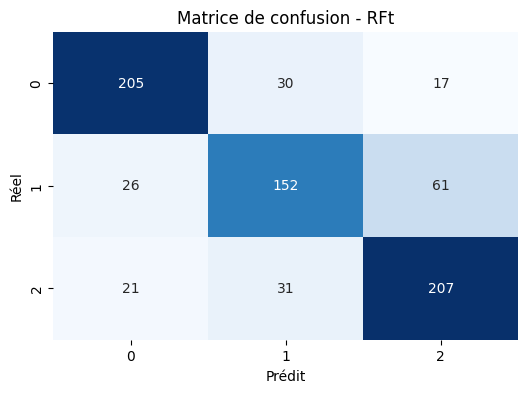

Précision pour RFt: 0.752
Sensibilité pour RFt: 0.7495677087727297
Spécificité pour RFt: 0.8723404255319149
Fiabilité pour RFt: 0.8818565400843882
Terminé !


In [ ]:
#Matrice de confusion avec la version des hyperparamètres d'Aurélie
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import seaborn as sns

# Charger le dataframe
# Charger le dataframe
df_signe = pd.read_csv("/content/drive/MyDrive/Capgemini/csv/signes.csv")

# Remplacer les NaN par 0
df_signe = df_signe.fillna(0)

# Colonnes d'entités (features)
colonnes_X = df_signe.columns.drop('classe')  # Sélectionner toutes les colonnes sauf 'classe'

X = df_signe[colonnes_X]
y = df_signe['classe']

# Séparation des données en ensemble d'entraînement et ensemble de test
# L'argument stratify de la fonction train_test_split() garantit que la distribution des classes dans l'ensemble d'entraînement et l'ensemble de test est similaire à celle de l'ensemble complet.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Supprimer la colonne video_name
X_train = X_train.drop(columns=['nom_video'])
X_test = X_test.drop(columns=['nom_video'])

# Liste des classifieurs à tester avec leurs acronymes respectifs
# Liste des classifieurs à tester avec leurs acronymes respectifs
parametres = {
    'RFt': {
        'n_estimators': 600,
        'max_depth': None,
        'min_samples_split': 5,
        'min_samples_leaf': 1,
        'random_state': 42
    }
}

# Utilisation des hyperparamètres spécifiés
classifieurs = {
    'RFt': RandomForestClassifier(**parametres['RFt'])
}



# Dictionnaires pour stocker les performances de chaque classifieur
resultats_precision = {}
resultats_sensibilite = {}
resultats_specificite = {}
resultats_fiabilite = {}

for nom_clf, clf in classifieurs.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn = cm[0, 0], cm[0, 1], cm[1, 0]
    tp = cm[1, 1] if cm.shape[0] == 2 else cm[1, 1:].sum()

    # Calcul des métriques
    precision = accuracy_score(y_test, y_pred)
    sensibilite = recall_score(y_test, y_pred, average='macro')
    specificite = tn / (tn + fp)
    fiabilite = (tp + tn) / (tp + tn + fp + fn)

    # Stockage des résultats
    resultats_precision[nom_clf] = precision
    resultats_sensibilite[nom_clf] = sensibilite
    resultats_specificite[nom_clf] = specificite
    resultats_fiabilite[nom_clf] = fiabilite

    # Affichage de la matrice de confusion avec annotations
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)


    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.title(f'Matrice de confusion - {nom_clf}')
    plt.show()

    print(f'Précision pour {nom_clf}: {precision}')
    print(f'Sensibilité pour {nom_clf}: {sensibilite}')
    print(f'Spécificité pour {nom_clf}: {specificite}')
    print(f'Fiabilité pour {nom_clf}: {fiabilite}')

print("Terminé !")



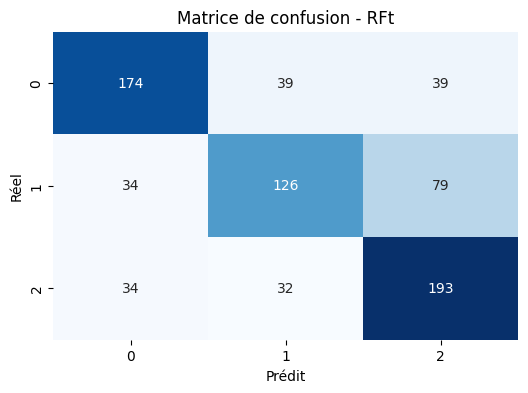

Précision pour RFt: 0.6573333333333333
Sensibilité pour RFt: 0.6542821961232003
Spécificité pour RFt: 0.8169014084507042
Fiabilité pour RFt: 0.838495575221239
Modèle RFt enregistré avec succès dans le dossier : /content/drive/MyDrive/Capgemini/modelesml
Terminé !


In [ ]:
#Matrice de confusion avec les paramètres par défauts
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import seaborn as sns

# Charger le dataframe
# Charger le dataframe
df_signe = pd.read_csv("/content/drive/MyDrive/Capgemini/csv/signes_sans_HOP_finished.csv")

# Remplacer les NaN par 0
df_signe = df_signe.fillna(0)

# Colonnes d'entités (features)
colonnes_X = df_signe.columns.drop('classe')  # Sélectionner toutes les colonnes sauf 'classe'

X = df_signe[colonnes_X]
y = df_signe['classe']

# Séparation des données en ensemble d'entraînement et ensemble de test
# L'argument stratify de la fonction train_test_split() garantit que la distribution des classes dans l'ensemble d'entraînement et l'ensemble de test est similaire à celle de l'ensemble complet.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Supprimer la colonne video_name
X_train = X_train.drop(columns=['nom_video'])
X_test = X_test.drop(columns=['nom_video'])

# Liste des classifieurs à tester avec leurs acronymes respectifs
# Liste des classifieurs à tester avec leurs acronymes respectifs

# Utilisation des hyperparamètres spécifiés
classifieurs = {
    'RFt': RandomForestClassifier(random_state=42),
}



# Dictionnaires pour stocker les performances de chaque classifieur
resultats_precision = {}
resultats_sensibilite = {}
resultats_specificite = {}
resultats_fiabilite = {}

for nom_clf, clf in classifieurs.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn = cm[0, 0], cm[0, 1], cm[1, 0]
    tp = cm[1, 1] if cm.shape[0] == 2 else cm[1, 1:].sum()

    # Calcul des métriques
    precision = accuracy_score(y_test, y_pred)
    sensibilite = recall_score(y_test, y_pred, average='macro')
    specificite = tn / (tn + fp)
    fiabilite = (tp + tn) / (tp + tn + fp + fn)

    # Stockage des résultats
    resultats_precision[nom_clf] = precision
    resultats_sensibilite[nom_clf] = sensibilite
    resultats_specificite[nom_clf] = specificite
    resultats_fiabilite[nom_clf] = fiabilite

    # Affichage de la matrice de confusion avec annotations
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)


    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.title(f'Matrice de confusion - {nom_clf}')
    plt.show()

    print(f'Précision pour {nom_clf}: {precision}')
    print(f'Sensibilité pour {nom_clf}: {sensibilite}')
    print(f'Spécificité pour {nom_clf}: {specificite}')
    print(f'Fiabilité pour {nom_clf}: {fiabilite}')

    # Enregistrement du modèle
    filename = os.path.join(dossier_enregistrement, f'modele_random_forest_v5_sans_HOP_par_def.pkl')
    joblib.dump(clf, filename)
    print(f"Modèle {nom_clf} enregistré avec succès dans le dossier :", dossier_enregistrement)


print("Terminé !")



In [ ]:
#étape 2 : vrai code Miora Machine Learning et enregistrer le fichier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import seaborn as sns
import joblib
import sklearn
import os
print(sklearn.__version__)


# Charger le dataframe
#df_signe = pd.read_table("/content/drive/MyDrive/Capgemini/csv/résultats_finaux.csv", sep=';', encoding='utf-8')
#
#df_signe = pd.read_csv("nouveau_resultats.csv")
df_signe = pd.read_csv("/content/drive/MyDrive/Capgemini/csv/signes.csv")

# Remplacer les NaN par 0
df_signe = df_signe.fillna(0)

# Colonnes d'entités (features)
colonnes_X = df_signe.columns.drop('classe')  # Sélectionner toutes les colonnes sauf 'classe'

X = df_signe[colonnes_X]
y = df_signe['classe']

# Séparation des données en ensemble d'entraînement et ensemble de test
# L'argument stratify de la fonction train_test_split() garantit que la distribution des classes dans l'ensemble d'entraînement et l'ensemble de test est similaire à celle de l'ensemble complet.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Supprimer la colonne nom_video
X_train = X_train.drop(columns=['nom_video'])
X_test = X_test.drop(columns=['nom_video'])


# Obtenir les valeurs uniques et leurs fréquences dans y_train et y_test
valeurs_unique_y_train = y_train.value_counts()
valeurs_unique_y_test = y_test.value_counts()

# Afficher les valeurs et leurs fréquences
print("Valeurs uniques et leurs fréquences dans y_train:")
print(valeurs_unique_y_train)

print("\nValeurs uniques et leurs fréquences dans y_test:")
print(valeurs_unique_y_test)


print("dim Xtrain:", X_train.shape)
print("dim Xtest :", X_test.shape)
print("dim X :",X.shape)
print("dim y : ",y.shape )
print("dim y_train :",y_train.shape)
print("dim y_test:",y_test.shape)
# Liste des classifieurs à tester avec leurs acronymes respectifs
classifieurs = {
    'RFt': RandomForestClassifier(random_state=42)
}

# Dictionnaires pour stocker les performances de chaque classifieur
resultats_precision = {}
resultats_sensibilite = {}
resultats_specificite = {}
resultats_fiabilite = {}

for nom_clf, clf in classifieurs.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn = cm[0, 0], cm[0, 1], cm[1, 0]
    tp = cm[1, 1] if cm.shape[0] == 2 else cm[1, 1:].sum()

    # Calcul des métriques
    precision = accuracy_score(y_test, y_pred)
    sensibilite = recall_score(y_test, y_pred, average='macro')
    specificite = tn / (tn + fp)
    fiabilite = (tp + tn) / (tp + tn + fp + fn)

    # Stockage des résultats
    resultats_precision[nom_clf] = precision
    resultats_sensibilite[nom_clf] = sensibilite
    resultats_specificite[nom_clf] = specificite
    resultats_fiabilite[nom_clf] = fiabilite

    print(f'Précision pour {nom_clf}: {precision}')
    print(f'Sensibilité pour {nom_clf}: {sensibilite}')
    print(f'Spécificité pour {nom_clf}: {specificite}')
    print(f'Fiabilité pour {nom_clf}: {fiabilite}')


# Dossier où enregistrer le modèle
dossier_enregistrement = "/content/drive/MyDrive/Capgemini/modelesml"

# Vérifier si le dossier existe, sinon le créer
if not os.path.exists(dossier_enregistrement):
    os.makedirs(dossier_enregistrement)

# Enregistrer le modèle
filename = os.path.join(dossier_enregistrement, 'modele_random_forest_v3.pkl')
joblib.dump(clf, filename)
print("Modèle enregistré avec succès dans le dossier :", dossier_enregistrement)
print('Terminé!')

1.2.2
Valeurs uniques et leurs fréquences dans y_train:
3    1036
1    1005
2     957
Name: classe, dtype: int64

Valeurs uniques et leurs fréquences dans y_test:
3    259
1    252
2    239
Name: classe, dtype: int64
dim Xtrain: (2998, 7000)
dim Xtest : (750, 7000)
dim X : (3748, 7001)
dim y :  (3748,)
dim y_train : (2998,)
dim y_test: (750,)
Précision pour RFt: 0.7373333333333333
Sensibilité pour RFt: 0.734657251393653
Spécificité pour RFt: 0.8782608695652174
Fiabilité pour RFt: 0.8805970149253731
Modèle enregistré avec succès dans le dossier : /content/drive/MyDrive/Capgemini/modelesml
Terminé!


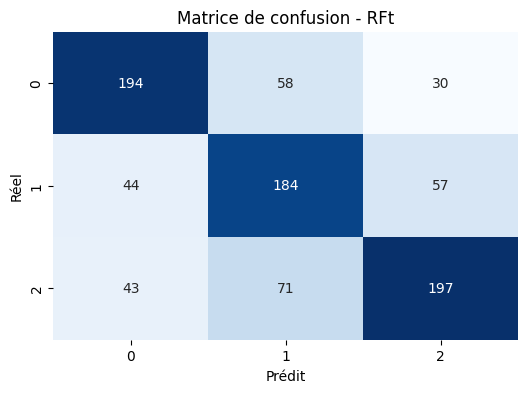

Précision pour RFt: 0.6548974943052391
Sensibilité pour RFt: 0.6556659373228401
Spécificité pour RFt: 0.7698412698412699
Fiabilité pour RFt: 0.8100558659217877


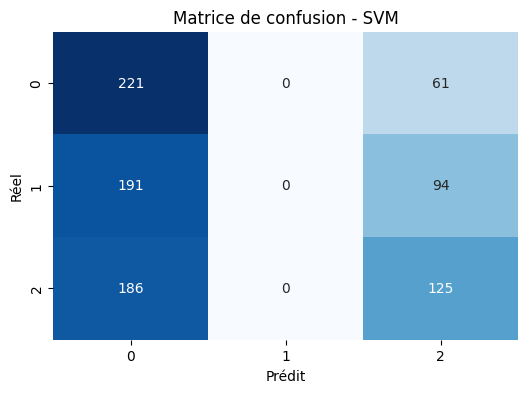

Précision pour SVM: 0.3940774487471526
Sensibilité pour SVM: 0.39520573457085734
Spécificité pour SVM: 1.0
Fiabilité pour SVM: 0.6225296442687747


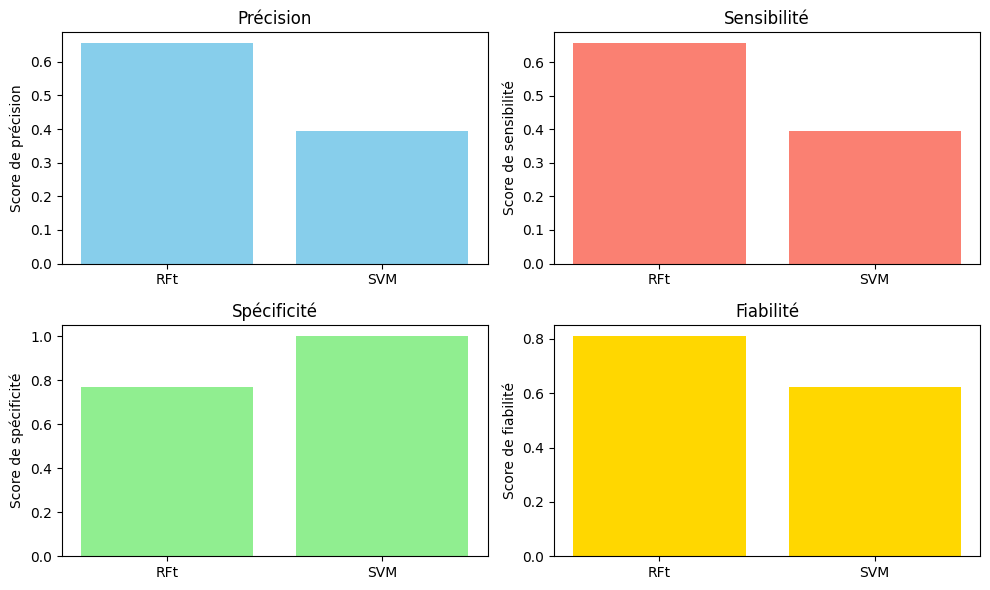

In [ ]:
#vrai code Miora Machine Learning
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import seaborn as sns

# Charger le dataframe
df_signe = pd.read_table("/content/drive/MyDrive/Capgemini/dataframe/final.csv", sep=';', encoding='utf-8')

# Remplacer les NaN par 0
df_signe = df_signe.fillna(0)

# Colonnes d'entités (features)
colonnes_X = df_signe.columns.drop('classe')  # Sélectionner toutes les colonnes sauf 'classe'

X = df_signe[colonnes_X]
y = df_signe['classe']

# Séparation des données en ensemble d'entraînement et ensemble de test
# L'argument stratify de la fonction train_test_split() garantit que la distribution des classes dans l'ensemble d'entraînement et l'ensemble de test est similaire à celle de l'ensemble complet.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Supprimer la colonne video_name
X_train = X_train.drop(columns=['video_name'])
X_test = X_test.drop(columns=['video_name'])

# Liste des classifieurs à tester avec leurs acronymes respectifs
classifieurs = {
    'RFt': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True)  # Activer la prédiction des probabilités
}

# Dictionnaires pour stocker les performances de chaque classifieur
resultats_precision = {}
resultats_sensibilite = {}
resultats_specificite = {}
resultats_fiabilite = {}

for nom_clf, clf in classifieurs.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn = cm[0, 0], cm[0, 1], cm[1, 0]
    tp = cm[1, 1] if cm.shape[0] == 2 else cm[1, 1:].sum()

    # Calcul des métriques
    precision = accuracy_score(y_test, y_pred)
    sensibilite = recall_score(y_test, y_pred, average='macro')
    specificite = tn / (tn + fp)
    fiabilite = (tp + tn) / (tp + tn + fp + fn)

    # Stockage des résultats
    resultats_precision[nom_clf] = precision
    resultats_sensibilite[nom_clf] = sensibilite
    resultats_specificite[nom_clf] = specificite
    resultats_fiabilite[nom_clf] = fiabilite

    # # Affichage de la matrice de confusion avec annotations
    # plt.figure(figsize=(6, 4))
    # sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)


    # plt.xlabel('Prédit')
    # plt.ylabel('Réel')
    # plt.title(f'Matrice de confusion - {nom_clf}')
    # plt.show()

    # print(f'Précision pour {nom_clf}: {precision}')
    # print(f'Sensibilité pour {nom_clf}: {sensibilite}')
    # print(f'Spécificité pour {nom_clf}: {specificite}')
    # print(f'Fiabilité pour {nom_clf}: {fiabilite}')

# Tracé des métriques pour chaque classifieur
plt.figure(figsize=(10, 6))

# Tracé de la précision
plt.subplot(2, 2, 1)
plt.bar(resultats_precision.keys(), resultats_precision.values(), color='skyblue')
plt.title('Précision')
plt.ylabel('Score de précision')

# Tracé de la sensibilité
plt.subplot(2, 2, 2)
plt.bar(resultats_sensibilite.keys(), resultats_sensibilite.values(), color='salmon')
plt.title('Sensibilité')
plt.ylabel('Score de sensibilité')

# Tracé de la spécificité
plt.subplot(2, 2, 3)
plt.bar(resultats_specificite.keys(), resultats_specificite.values(), color='lightgreen')
plt.title('Spécificité')
plt.ylabel('Score de spécificité')

# Tracé de la fiabilité
plt.subplot(2, 2, 4)
plt.bar(resultats_fiabilite.keys(), resultats_fiabilite.values(), color='gold')
plt.title('Fiabilité')
plt.ylabel('Score de fiabilité')

plt.tight_layout()
plt.show()


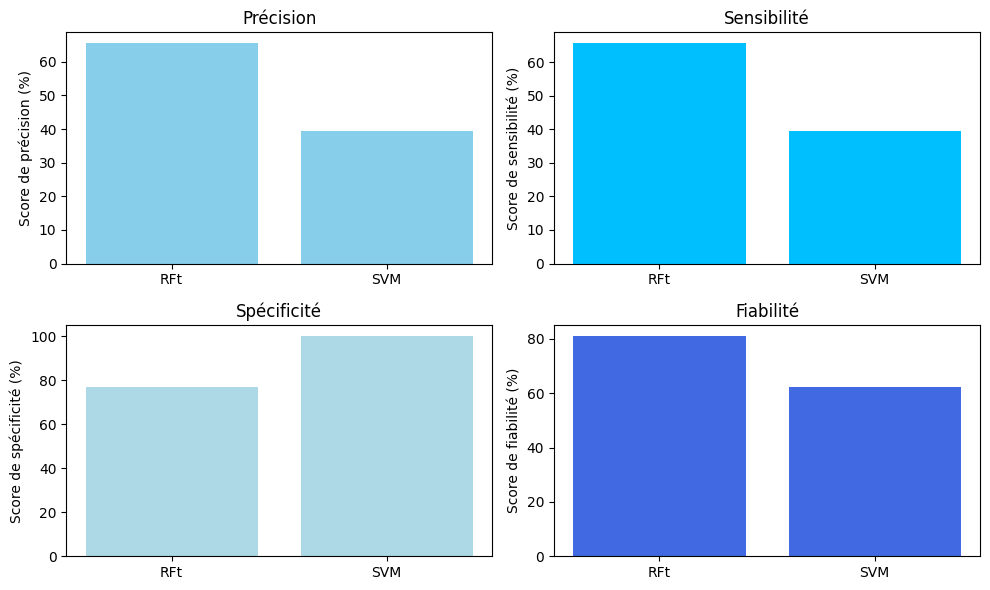

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import seaborn as sns

# Charger le dataframe
df_signe = pd.read_table("/content/drive/MyDrive/Capgemini/dataframe/final.csv", sep=';', encoding='utf-8')

# Remplacer les NaN par 0
df_signe = df_signe.fillna(0)

# Colonnes d'entités (features)
colonnes_X = df_signe.columns.drop('classe')  # Sélectionner toutes les colonnes sauf 'classe'

X = df_signe[colonnes_X]
y = df_signe['classe']

# Séparation des données en ensemble d'entraînement et ensemble de test
# L'argument stratify de la fonction train_test_split() garantit que la distribution des classes dans l'ensemble d'entraînement et l'ensemble de test est similaire à celle de l'ensemble complet.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Supprimer la colonne video_name
X_train = X_train.drop(columns=['video_name'])
X_test = X_test.drop(columns=['video_name'])

# Liste des classifieurs à tester avec leurs acronymes respectifs
classifieurs = {
    'RFt': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True)  # Activer la prédiction des probabilités
}

# Dictionnaires pour stocker les performances de chaque classifieur
resultats_precision = {}
resultats_sensibilite = {}
resultats_specificite = {}
resultats_fiabilite = {}

for nom_clf, clf in classifieurs.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn = cm[0, 0], cm[0, 1], cm[1, 0]
    tp = cm[1, 1] if cm.shape[0] == 2 else cm[1, 1:].sum()

    # Calcul des métriques en pourcentage
    precision = accuracy_score(y_test, y_pred) * 100
    sensibilite = recall_score(y_test, y_pred, average='macro') * 100
    specificite = (tn / (tn + fp)) * 100
    fiabilite = ((tp + tn) / (tp + tn + fp + fn)) * 100

    # Stockage des résultats
    resultats_precision[nom_clf] = precision
    resultats_sensibilite[nom_clf] = sensibilite
    resultats_specificite[nom_clf] = specificite
    resultats_fiabilite[nom_clf] = fiabilite

# Tracé des métriques pour chaque classifieur
plt.figure(figsize=(10, 6))

# Tracé de la précision
plt.subplot(2, 2, 1)
plt.bar(resultats_precision.keys(), resultats_precision.values(), color='skyblue')
plt.title('Précision')
plt.ylabel('Score de précision (%)')

# Tracé de la sensibilité
plt.subplot(2, 2, 2)
plt.bar(resultats_sensibilite.keys(), resultats_sensibilite.values(), color='deepskyblue')
plt.title('Sensibilité')
plt.ylabel('Score de sensibilité (%)')

# Tracé de la spécificité
plt.subplot(2, 2, 3)
plt.bar(resultats_specificite.keys(), resultats_specificite.values(), color='lightblue')
plt.title('Spécificité')
plt.ylabel('Score de spécificité (%)')

# Tracé de la fiabilité
plt.subplot(2, 2, 4)
plt.bar(resultats_fiabilite.keys(), resultats_fiabilite.values(), color='royalblue')
plt.title('Fiabilité')
plt.ylabel('Score de fiabilité (%)')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import seaborn as sns

# Charger le dataframe
df_signe = pd.read_table("/content/drive/MyDrive/Capgemini/dataframe/final.csv", sep=';', encoding='utf-8')

# Remplacer les NaN par 0
df_signe = df_signe.fillna(0)

# Colonnes d'entités (features)
colonnes_X = df_signe.columns.drop('classe')  # Sélectionner toutes les colonnes sauf 'classe'

X = df_signe[colonnes_X]
y = df_signe['classe']

# Séparation des données en ensemble d'entraînement et ensemble de test
# L'argument stratify de la fonction train_test_split() garantit que la distribution des classes dans l'ensemble d'entraînement et l'ensemble de test est similaire à celle de l'ensemble complet.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Supprimer la colonne video_name
X_train = X_train.drop(columns=['video_name'])
X_test = X_test.drop(columns=['video_name'])

# Liste des classifieurs à tester avec leurs acronymes respectifs
classifieurs = {
    'RFt': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True)  # Activer la prédiction des probabilités
}

# Dictionnaires pour stocker les performances de chaque classifieur
resultats_precision = {}
resultats_sensibilite = {}
resultats_specificite = {}
resultats_fiabilite = {}
matrices_confusion = {}

for nom_clf, clf in classifieurs.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    matrices_confusion[nom_clf] = confusion_matrix(y_test, y_pred)
    tn, fp, fn = cm[0, 0], cm[0, 1], cm[1, 0]
    tp = cm[1, 1] if cm.shape[0] == 2 else cm[1, 1:].sum()

# Imprimer les matrices de confusion
for nom_clf, cm in matrices_confusion.items():
    print(f"Matrice de confusion - {nom_clf}:")
    print(cm)


Matrice de confusion - RFt:
[[194  58  30]
 [ 44 184  57]
 [ 43  71 197]]
Matrice de confusion - SVM:
[[221   0  61]
 [191   0  94]
 [186   0 125]]


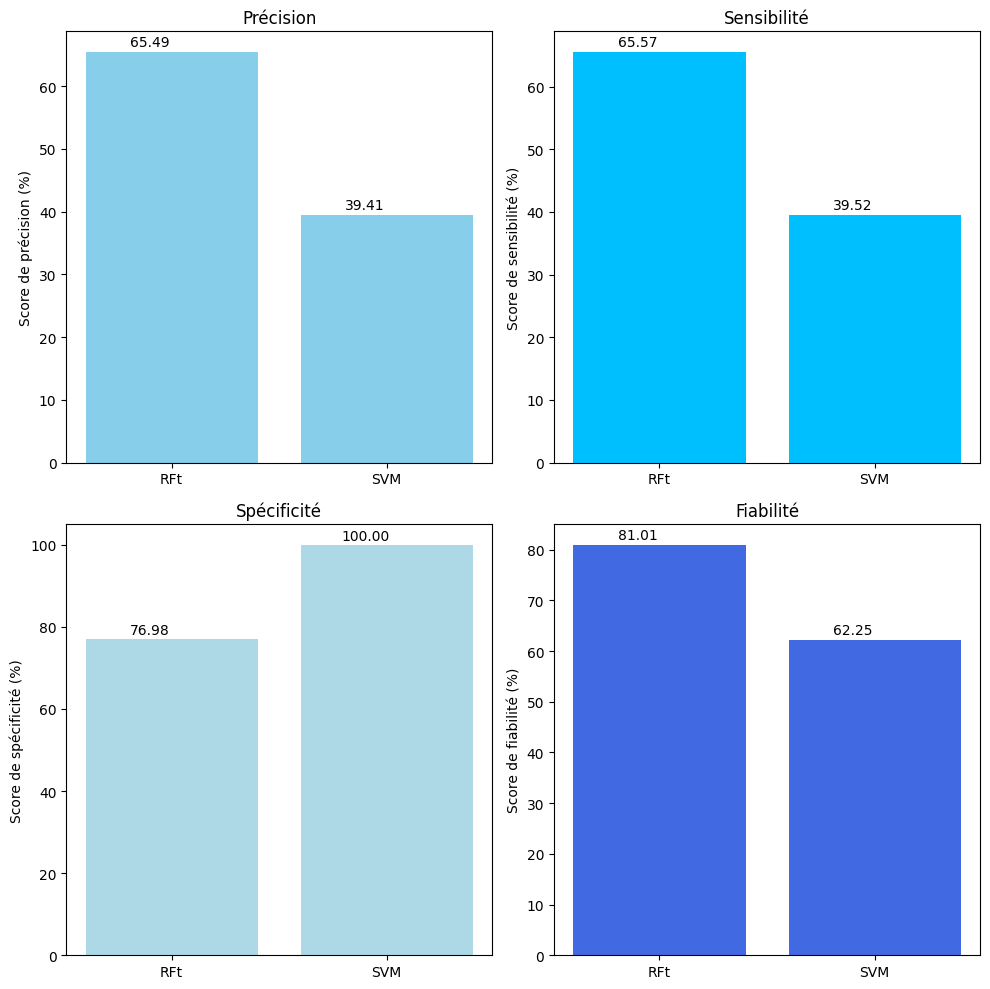

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import seaborn as sns

# Charger le dataframe
df_signe = pd.read_table("/content/drive/MyDrive/Capgemini/dataframe/final.csv", sep=';', encoding='utf-8')

# Remplacer les NaN par 0
df_signe = df_signe.fillna(0)

# Colonnes d'entités (features)
colonnes_X = df_signe.columns.drop('classe')  # Sélectionner toutes les colonnes sauf 'classe'

X = df_signe[colonnes_X]
y = df_signe['classe']

# Séparation des données en ensemble d'entraînement et ensemble de test
# L'argument stratify de la fonction train_test_split() garantit que la distribution des classes dans l'ensemble d'entraînement et l'ensemble de test est similaire à celle de l'ensemble complet.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Supprimer la colonne video_name
X_train = X_train.drop(columns=['video_name'])
X_test = X_test.drop(columns=['video_name'])

# Liste des classifieurs à tester avec leurs acronymes respectifs
classifieurs = {
    'RFt': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True)  # Activer la prédiction des probabilités
}

# Dictionnaires pour stocker les performances de chaque classifieur
resultats_precision = {}
resultats_sensibilite = {}
resultats_specificite = {}
resultats_fiabilite = {}

for nom_clf, clf in classifieurs.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn = cm[0, 0], cm[0, 1], cm[1, 0]
    tp = cm[1, 1] if cm.shape[0] == 2 else cm[1, 1:].sum()

    # Calcul des métriques en pourcentage
    precision = accuracy_score(y_test, y_pred) * 100
    sensibilite = recall_score(y_test, y_pred, average='macro') * 100
    specificite = (tn / (tn + fp)) * 100
    fiabilite = ((tp + tn) / (tp + tn + fp + fn)) * 100

    # Stockage des résultats
    resultats_precision[nom_clf] = precision
    resultats_sensibilite[nom_clf] = sensibilite
    resultats_specificite[nom_clf] = specificite
    resultats_fiabilite[nom_clf] = fiabilite

# Tracé des métriques pour chaque classifieur
plt.figure(figsize=(10, 10))

# Tracé de la précision
plt.subplot(2, 2, 1)
bars = plt.bar(resultats_precision.keys(), resultats_precision.values(), color='skyblue')
plt.title('Précision')
plt.ylabel('Score de précision (%)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height() + 0.5, f'{bar.get_height():.2f}', ha='center', va='bottom')

# Tracé de la sensibilité
plt.subplot(2, 2, 2)
bars = plt.bar(resultats_sensibilite.keys(), resultats_sensibilite.values(), color='deepskyblue')
plt.title('Sensibilité')
plt.ylabel('Score de sensibilité (%)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height() + 0.5, f'{bar.get_height():.2f}', ha='center', va='bottom')

# Tracé de la spécificité
plt.subplot(2, 2, 3)
bars = plt.bar(resultats_specificite.keys(), resultats_specificite.values(), color='lightblue')
plt.title('Spécificité')
plt.ylabel('Score de spécificité (%)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height() + 0.5, f'{bar.get_height():.2f}', ha='center', va='bottom')

# Tracé de la fiabilité
plt.subplot(2, 2, 4)
bars = plt.bar(resultats_fiabilite.keys(), resultats_fiabilite.values(), color='royalblue')
plt.title('Fiabilité')
plt.ylabel('Score de fiabilité (%)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height() + 0.5, f'{bar.get_height():.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


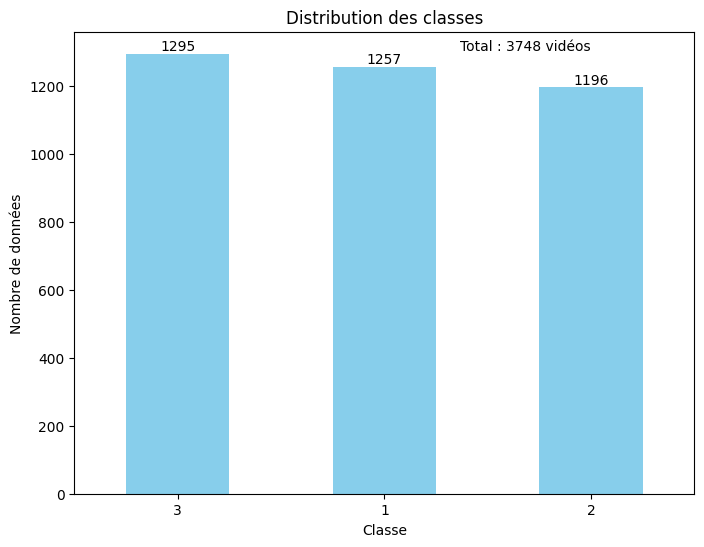

Nombre total de données : 3748


In [ ]:
#distribution des classes
import pandas as pd
import matplotlib.pyplot as plt

# Charger le dataframe
df_signe = pd.read_csv("/content/drive/MyDrive/Capgemini/csv/signes.csv")
#/content/drive/MyDrive/Capgemini/csv/dataframe_ML.csv

# Obtenir la distribution des classes
classe_distribution = df_signe['classe'].value_counts()

# Tracer l'histogramme
plt.figure(figsize=(8, 6))
barplot = classe_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution des classes')
plt.xlabel('Classe')
plt.ylabel('Nombre de données')
plt.xticks(rotation=0)  # Rotation des étiquettes sur l'axe x

# Ajouter le nombre au dessus de chaque barre
for index, value in enumerate(classe_distribution):
    barplot.text(index, value + 1, str(value), ha='center', va='bottom')

# Calculer et afficher le total des valeurs
total_values = classe_distribution.sum()
plt.text(len(classe_distribution) - 1, classe_distribution.max() + 10, f"Total : {total_values} vidéos", ha='right', fontsize=10)

plt.show()

# Afficher le nombre total de données (lignes)
print("Nombre total de données :", len(df_signe))


In [ ]:
#distribution des classes
import pandas as pd
import matplotlib.pyplot as plt

# Charger le dataframe
df_signe = pd.read_table("/content/drive/MyDrive/Capgemini/dataframe/final.csv", sep=';', encoding='utf-8')
#/content/drive/MyDrive/Capgemini/csv/dataframe_ML.csv

# Obtenir la distribution des classes
classe_distribution = df_signe['classe'].value_counts()

# Tracer l'histogramme
plt.figure(figsize=(8, 6))
barplot = classe_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution des classes')
plt.xlabel('Classe')
plt.ylabel('Nombre de données')
plt.xticks(rotation=0)  # Rotation des étiquettes sur l'axe x

# Ajouter le nombre au dessus de chaque barre
for index, value in enumerate(classe_distribution):
    barplot.text(index, value + 1, str(value), ha='center', va='bottom')

# Calculer et afficher le total des valeurs
total_values = classe_distribution.sum()
plt.text(len(classe_distribution) - 1, classe_distribution.max() + 10, f"Total : {total_values} vidéos", ha='right', fontsize=10)

plt.show()

# Afficher le nombre total de données (lignes)
print("Nombre total de données :", len(df_signe))


In [ ]:
#distribution des classes
import pandas as pd
import matplotlib.pyplot as plt

# Charger le dataframe
df_signe = pd.read_table("/content/drive/MyDrive/Capgemini/dataframe/final.csv", sep=';', encoding='utf-8')
#/content/drive/MyDrive/Capgemini/csv/dataframe_ML.csv

# Obtenir la distribution des classes
classe_distribution = df_signe['classe'].value_counts()

# Tracer l'histogramme
plt.figure(figsize=(8, 6))
barplot = classe_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution des classes')
plt.xlabel('Classe')
plt.ylabel('Nombre de données')
plt.xticks(rotation=0)  # Rotation des étiquettes sur l'axe x

# Ajouter le nombre au dessus de chaque barre
for index, value in enumerate(classe_distribution):
    barplot.text(index, value + 1, str(value), ha='center', va='bottom')

# Calculer et afficher le total des valeurs
total_values = classe_distribution.sum()
plt.text(len(classe_distribution) - 1, classe_distribution.max() + 10, f"Total : {total_values} vidéos", ha='right', fontsize=10)

plt.show()

# Afficher le nombre total de données (lignes)
print("Nombre total de données :", len(df_signe))


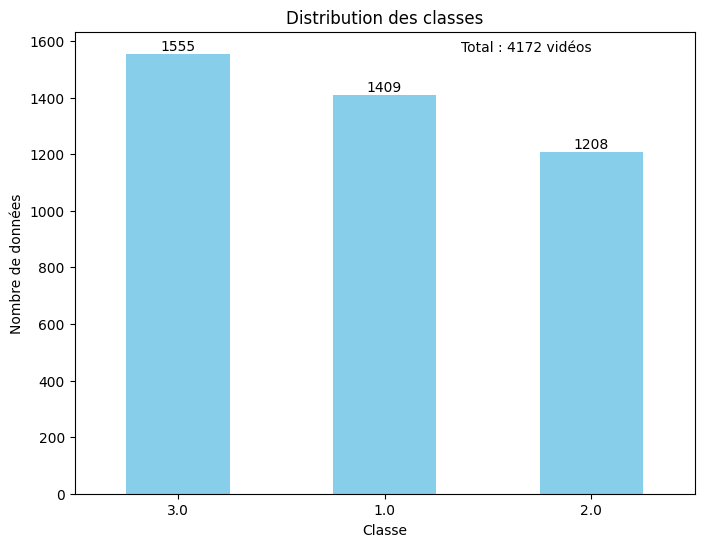

Nombre total de données : 4188


In [ ]:
#distribution des classes
import pandas as pd
import matplotlib.pyplot as plt

# Charger le dataframe
#df_signe = pd.read_table("/content/drive/MyDrive/Capgemini/dataframe/final.csv", sep=';', encoding='utf-8')
df_signe = pd.read_csv("/content/drive/MyDrive/Capgemini/csv/nouveau_resultats.csv")

# Obtenir la distribution des classes
classe_distribution = df_signe['classe'].value_counts()

# Tracer l'histogramme
plt.figure(figsize=(8, 6))
barplot = classe_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution des classes')
plt.xlabel('Classe')
plt.ylabel('Nombre de données')
plt.xticks(rotation=0)  # Rotation des étiquettes sur l'axe x

# Ajouter le nombre au dessus de chaque barre
for index, value in enumerate(classe_distribution):
    barplot.text(index, value + 1, str(value), ha='center', va='bottom')

# Calculer et afficher le total des valeurs
total_values = classe_distribution.sum()
plt.text(len(classe_distribution) - 1, classe_distribution.max() + 10, f"Total : {total_values} vidéos", ha='right', fontsize=10)

plt.show()

# Afficher le nombre total de données (lignes)
print("Nombre total de données :", len(df_signe))


In [ ]:
import pandas as pd

# Montez Google Drive pour accéder au fichier CSV
from google.colab import drive
drive.mount('/content/drive')

# Spécifiez le chemin vers le fichier CSV
chemin_fichier = "/content/drive/MyDrive/Capgemini/csv/résultats_finaux.csv"

# Charger le fichier CSV dans un dataframe
df = pd.read_csv(chemin_fichier)

# Créer un nouveau dataframe en supprimant les colonnes commençant par "Ferme_"
nouveau_df = df.drop(df.columns[df.columns.str.startswith('Ferme_')], axis=1)

# Sauvegarder le nouveau dataframe dans un nouveau fichier CSV
nouveau_df.to_csv("/content/drive/MyDrive/Capgemini/csv/nouveau_resultats.csv", index=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#distribution des classes
import pandas as pd
import matplotlib.pyplot as plt

# Charger le dataframe
df_signe = pd.read_table("/content/drive/MyDrive/Capgemini/csv/final.csv", sep=';', encoding='utf-8')

# Obtenir la distribution des classes
classe_distribution = df_signe['classe'].value_counts()

# Tracer l'histogramme
plt.figure(figsize=(8, 6))
barplot = classe_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution des classes')
plt.xlabel('Classe')
plt.ylabel('Nombre de données')
plt.xticks(rotation=0)  # Rotation des étiquettes sur l'axe x

# Ajouter le nombre au dessus de chaque barre
for index, value in enumerate(classe_distribution):
    barplot.text(index, value + 1, str(value), ha='center', va='bottom')

# Calculer et afficher le total des valeurs
total_values = classe_distribution.sum()
plt.text(len(classe_distribution) - 1, classe_distribution.max() + 10, f"Total : {total_values} vidéos", ha='right', fontsize=10)

plt.show()

# Afficher le nombre total de données (lignes)
print("Nombre total de données :", len(df_signe))


In [ ]:
#distribution des 3 classes
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

# Charger le dataframe
df_signe = pd.read_table("/content/drive/MyDrive/Capgemini/dataframe/final.csv", sep=';', encoding='utf-8')

# Remplacer les NaN par 0
df_signe = df_signe.fillna(0)

# Colonnes d'entités (features)
X_columns = df_signe.columns.drop('classe')  # Sélectionner toutes les colonnes sauf 'classe'

X = df_signe[X_columns]
y = df_signe['classe']

# Séparation des données en ensemble d'entraînement et ensemble de test
#argument stratify de la fonction train_test_split(). Cela garantira que la distribution des classes dans l'ensemble d'entraînement et l'ensemble de test sera similaire à celle de l'ensemble complet.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("X_train",X_train)
print("X_test",X_test)
print("y_train",y_train)
print("y_test",y_test)


# # Calculer les occurrences de chaque classe dans y_train et y_test
# train_counts = y_train.value_counts().sort_index()
# test_counts = y_test.value_counts().sort_index()

# # Créer la figure
# plt.figure(figsize=(10, 5))

# # Plot pour y_train
# plt.subplot(1, 2, 1)
# bars_train = plt.bar(train_counts.index, train_counts.values, color='lightblue')
# plt.title(f'Distribution des classes dans y_train sur {len(y_train)} vidéos')
# plt.xlabel('Classe')
# plt.ylabel('Nombre d\'occurrences')

# # Ajouter les nombres sur les barres pour y_train
# for bar in bars_train:
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(int(bar.get_height())),
#              ha='center', va='bottom')

# # Plot pour y_test
# plt.subplot(1, 2, 2)
# bars_test = plt.bar(test_counts.index, test_counts.values, color='lightsteelblue')
# plt.title(f'Distribution des classes dans y_test sur {len(y_test)} vidéos')
# plt.xlabel('Classe')
# plt.ylabel('Nombre d\'occurrences')

# # Ajouter les nombres sur les barres pour y_test
# for bar in bars_test:
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(int(bar.get_height())),
#              ha='center', va='bottom')

# plt.tight_layout()
# plt.show()





X_train.reset_index(drop=True, inplace=True)

# Liste des classifieurs à tester avec leurs acronymes respectifs
classifiers = {
    'RFt': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True)  # Activer la prédiction des probabilités
}

# Dictionnaires pour stocker les performances de chaque classifieur
accuracy_results = {}
sensibility_results = {}
specificity_results = {}
reliability_results = {}

# Entraînement, évaluation et collecte des performances pour chaque classifieur
for clf_name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Obtenir les probabilités pour la classe positive

    # Calcul des performances
    accuracy = accuracy_score(y_test, y_pred)
    sensibility = recall_score(y_test, y_pred, average=None)
    conf_matrix = confusion_matrix(y_test, y_pred)
    TN, FP, _, _ = conf_matrix.ravel()
    specificity = TN / (TN + FP)
    reliability = y_pred_proba.mean()

    # Stockage des performances
    accuracy_results[clf_name] = accuracy
    sensibility_results[clf_name] = sensibility
    specificity_results[clf_name] = specificity
    reliability_results[clf_name] = reliability

# Tracé des résultats pour chaque métrique
plt.figure(figsize=(12, 8))

print(conf_matrix)

# Précision
plt.subplot(2, 2, 1)
bars = plt.bar(accuracy_results.keys(), accuracy_results.values())
plt.title('Précision du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')

# Sensibilité
plt.subplot(2, 2, 2)
bars = plt.bar(sensibility_results.keys(), sensibility_results['RFt'])  # Juste pour le classifieur RandomForest
plt.title('Sensibilité du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')

# Spécificité
plt.subplot(2, 2, 3)
bars = plt.bar(specificity_results.keys(), specificity_results.values())
plt.title('Spécificité du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')

# Fiabilité
plt.subplot(2, 2, 4)
bars = plt.bar(reliability_results.keys(), reliability_results.values())
plt.title('Fiabilité du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()


X_train                                              video_name     MAR_0  EAR_left_0  \
1509  /content/drive/MyDrive/Capgemini/delmas/rldd/3...  0.379598    0.280271   
3842  /content/drive/MyDrive/Capgemini/delmas/rldd/1...  0.285262    0.302351   
1794  /content/drive/MyDrive/Capgemini/delmas/rldd/2...  0.335315    0.301629   
1392  /content/drive/MyDrive/Capgemini/delmas/rldd/3...  0.290300    0.250155   
1060  /content/drive/MyDrive/Capgemini/delmas/rldd/3...  0.344443    0.307093   
...                                                 ...       ...         ...   
3285  /content/drive/MyDrive/Capgemini/delmas/rldd/1...  0.394907    0.186766   
2606  /content/drive/MyDrive/Capgemini/delmas/rldd/2...  0.000000    0.000000   
2609  /content/drive/MyDrive/Capgemini/delmas/rldd/2...  0.000000    0.000000   
820   /content/drive/MyDrive/Capgemini/delmas/rldd/3...  0.378510    0.238970   
2725  /content/drive/MyDrive/Capgemini/delmas/rldd/2...  0.000000    0.000000   

      EAR_right_0  

ValueError: could not convert string to float: '/content/drive/MyDrive/Capgemini/delmas/rldd/3#kss#8-9#F#rldd#60-10#004.mp4'

In [ ]:
import pandas as pd

# Chemins des fichiers CSV
file1_path = "/content/drive/MyDrive/Capgemini/dataframe/data_with_classe(tableur).csv"
file2_path = "/content/drive/MyDrive/Capgemini/dataframe/datatoaddwithheader_with_classe(tableur).csv"

# Lire les fichiers CSV
df1 = pd.read_csv(file1_path, sep=';', encoding='utf-8')
df2 = pd.read_csv(file2_path, sep=';', encoding='utf-8')

# Assurez-vous que les deux DataFrames ont la même entête
assert all(df1.columns == df2.columns), "Les entêtes des DataFrames ne correspondent pas"

# Concaténer les deux DataFrames
df_concat = pd.concat([df1, df2], ignore_index=True)

# Écrire le DataFrame résultant dans un fichier CSV
output_path = "/content/drive/MyDrive/Capgemini/dataframe/concatenated_data.csv"
df_concat.to_csv(output_path, sep=';', index=False, encoding='utf-8')


In [ ]:
#distribution des 3 classes
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

# Charger le dataframe
df_signe = pd.read_csv("/content/drive/MyDrive/Capgemini/csv/nouveau_resultats.csv")
# Remplacer les NaN par 0
df_signe = df_signe.fillna(0)

# Colonnes d'entités (features)
X_columns = df_signe.columns.drop('classe')  # Sélectionner toutes les colonnes sauf 'classe'

X = df_signe[X_columns]
y = df_signe['classe']

# Séparation des données en ensemble d'entraînement et ensemble de test
#argument stratify de la fonction train_test_split(). Cela garantira que la distribution des classes dans l'ensemble d'entraînement et l'ensemble de test sera similaire à celle de l'ensemble complet.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("X_train",X_train)
print("X_test",X_test)
print("y_train",y_train)
print("y_test",y_test)


# # Calculer les occurrences de chaque classe dans y_train et y_test
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()
print("train_counts" , train_counts)
print("test_counts" , test_counts)


# # Créer la figure
# plt.figure(figsize=(10, 5))

# # Plot pour y_train
# plt.subplot(1, 2, 1)
# bars_train = plt.bar(train_counts.index, train_counts.values, color='lightblue')
# plt.title(f'Distribution des classes dans y_train sur {len(y_train)} vidéos')
# plt.xlabel('Classe')
# plt.ylabel('Nombre d\'occurrences')

# # Ajouter les nombres sur les barres pour y_train
# for bar in bars_train:
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(int(bar.get_height())),
#              ha='center', va='bottom')

# # Plot pour y_test
# plt.subplot(1, 2, 2)
# bars_test = plt.bar(test_counts.index, test_counts.values, color='lightsteelblue')
# plt.title(f'Distribution des classes dans y_test sur {len(y_test)} vidéos')
# plt.xlabel('Classe')
# plt.ylabel('Nombre d\'occurrences')

# # Ajouter les nombres sur les barres pour y_test
# for bar in bars_test:
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(int(bar.get_height())),
#              ha='center', va='bottom')

# plt.tight_layout()
# plt.show()





# X_train.reset_index(drop=True, inplace=True)

# # Liste des classifieurs à tester avec leurs acronymes respectifs
# classifiers = {
#     'RFt': RandomForestClassifier(random_state=42)
# }

# # Dictionnaires pour stocker les performances de chaque classifieur
# accuracy_results = {}
# sensibility_results = {}
# specificity_results = {}
# reliability_results = {}

# # Entraînement, évaluation et collecte des performances pour chaque classifieur
# for clf_name, clf in classifiers.items():
#     clf.fit(X_train, y_train)
#     y_pred = clf.predict(X_test)
#     y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Obtenir les probabilités pour la classe positive

#     # Calcul des performances
#     accuracy = accuracy_score(y_test, y_pred)
#     sensibility = recall_score(y_test, y_pred, average=None)
#     conf_matrix = confusion_matrix(y_test, y_pred)
#     TN, FP, _, _ = conf_matrix.ravel()
#     specificity = TN / (TN + FP)
#     reliability = y_pred_proba.mean()

#     # Stockage des performances
#     accuracy_results[clf_name] = accuracy
#     sensibility_results[clf_name] = sensibility
#     specificity_results[clf_name] = specificity
#     reliability_results[clf_name] = reliability

# # Tracé des résultats pour chaque métrique
# plt.figure(figsize=(12, 8))

# print(conf_matrix)

# # Précision
# plt.subplot(2, 2, 1)
# bars = plt.bar(accuracy_results.keys(), accuracy_results.values())
# plt.title('Précision du modèle')
# for bar in bars:
#     yval = round(bar.get_height(), 2)
#     plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')

# # Sensibilité
# plt.subplot(2, 2, 2)
# bars = plt.bar(sensibility_results.keys(), sensibility_results['RFt'])  # Juste pour le classifieur RandomForest
# plt.title('Sensibilité du modèle')
# for bar in bars:
#     yval = round(bar.get_height(), 2)
#     plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')

# # Spécificité
# plt.subplot(2, 2, 3)
# bars = plt.bar(specificity_results.keys(), specificity_results.values())
# plt.title('Spécificité du modèle')
# for bar in bars:
#     yval = round(bar.get_height(), 2)
#     plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')

# # Fiabilité
# plt.subplot(2, 2, 4)
# bars = plt.bar(reliability_results.keys(), reliability_results.values())
# plt.title('Fiabilité du modèle')
# for bar in bars:
#     yval = round(bar.get_height(), 2)
#     plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')

# plt.tight_layout()
# plt.show()


X_train                            nom_video  EAR_left_0  EAR_right_0  EAR_mean_0  \
4149  3#kss#8-9#F#rldd#13-10#024.mp4    0.000000     0.000000    0.000000   
95     2#kss#6-7#F#rldd#34-5#013.mp4    0.284559     0.291351    0.287955   
1041   1#kss#1-3#F#rldd#37-0#031.mp4    0.080343     0.073087    0.076715   
1405   2#kss#6-7#F#rldd#03-5#011.mp4    0.202972     0.192441    0.197707   
781    2#kss#6-7#F#rldd#60-5#012.mp4    0.274822     0.284642    0.279732   
...                              ...         ...          ...         ...   
2757   1#kss#1-3#F#rldd#38-0#011.mp4    0.000000     0.000000    0.000000   
2940  3#kss#8-9#F#rldd#21-10#025.mp4    0.242506     0.270352    0.256429   
2941  3#kss#8-9#F#rldd#21-10#022.mp4    0.263643     0.287691    0.275667   
2564   1#kss#1-3#F#rldd#28-0#025.mp4    0.188155     0.226435    0.207295   
2076   1#kss#1-3#F#rldd#07-0#007.mp4    0.113663     0.144228    0.128946   

         MAR_0  EBR_0  PERCLOS_0    HOP_gd_0    HOP_hb_0  EAR_left_

In [ ]:
import pandas as pd

# Charger le fichier CSV existant avec l'en-tête
df = pd.read_csv("/content/drive/MyDrive/Capgemini/dataframe/datatoaddwithheader.csv")

# Supprimer l'en-tête
df_no_header = df.iloc[1:]

# Enregistrer le DataFrame sans l'en-tête dans un nouveau fichier CSV
df_no_header.to_csv("/content/drive/MyDrive/Capgemini/dataframe/datatoaddwithoutheader.csv", index=False)


In [ ]:
import pandas as pd
df_signe = pd.read_table("/content/drive/MyDrive/Capgemini/dataframe/final.csv", sep = ';', encoding='utf-8') # Lecture des données csv
#print(df_signe['video_name'] )     # Affichage des 5 premières lignes pour voir à quoi ressemble les différentes données
# Afficher les noms des colonnes
print(df_signe.columns)
print(df_signe['video_name'] )

import pandas as pd

# Obtenir les dimensions du DataFrame
dimensions = df_signe.shape

# Affichage des dimensions
print("Nombre de lignes :", dimensions[0])
print("Nombre de colonnes :", dimensions[1])



Index(['video_name', 'classe', 'MAR_0', 'EAR_left_0', 'EAR_right_0',
       'EAR_moyen_0', 'HOP_gd_0', 'HOP_hb_0', 'MAR_1', 'EAR_left_1',
       ...
       'EAR_right_873', 'EAR_moyen_873', 'HOP_gd_873', 'HOP_hb_873', 'MAR_874',
       'EAR_left_874', 'EAR_right_874', 'EAR_moyen_874', 'HOP_gd_874',
       'HOP_hb_874'],
      dtype='object', length=5262)
0       /content/drive/MyDrive/Capgemini/delmas/rldd/3...
1       /content/drive/MyDrive/Capgemini/delmas/rldd/3...
2       /content/drive/MyDrive/Capgemini/delmas/rldd/3...
3       /content/drive/MyDrive/Capgemini/delmas/rldd/3...
4       /content/drive/MyDrive/Capgemini/delmas/rldd/3...
                              ...                        
4385    /content/drive/MyDrive/Capgemini/delmas/rldd/1...
4386    /content/drive/MyDrive/Capgemini/delmas/rldd/1...
4387    /content/drive/MyDrive/Capgemini/delmas/rldd/1...
4388    /content/drive/MyDrive/Capgemini/delmas/rldd/1...
4389    /content/drive/MyDrive/Capgemini/delmas/rldd/1...
Name:

In [ ]:
import pandas as pd

# Lire le fichier CSV en spécifiant le délimiteur
df_signe = pd.read_csv("/content/drive/MyDrive/Capgemini/dataframe/dataframe_final_tests.csv")

print(df_signe)



  /content/drive/MyDrive/Capgemini/testvideos/3#kss#8-9#F#rldd#56-10#018.mp4  \
0  /content/drive/MyDrive/Capgemini/testvideos/1#...                           
1  /content/drive/MyDrive/Capgemini/testvideos/2#...                           

   0.29183307886849147  0.30574948629646775  0.2984083050865436  \
0             0.291615             0.329814            0.322638   
1             0.291361             0.329507            0.322309   

   0.3020788956915057  89.99527098363166  0.28459898705605724  -1  -1.1  \
0            0.326226          89.996863             0.495327  -1    -1   
1            0.325908          89.996887             0.491036  -1    -1   

   0.2833192049459065  ...  -1.1738  -1.1739  0.28279677579819207  \
0            0.290568  ...       -1       -1             0.282970   
1            0.290432  ...       -1       -1             0.282799   

   0.26408136409630384  0.2583102591592138  0.26119581162775884  \
0             0.264142            0.258410             0

In [ ]:
import pandas as pd

# Charger le DataFrame depuis le fichier CSV
df_signe = pd.read_csv("/content/drive/MyDrive/Capgemini/dataframe/data_with_classe.csv")

# Sélectionner les cinq premières lignes
df_cinq_premieres_lignes = df_signe.head(5)

# Écrire ces cinq premières lignes dans un nouveau fichier CSV dans le même dossier
chemin_dossier = "/content/drive/MyDrive/Capgemini/dataframe/"
nom_fichier = "data_with_classe_5_rows.csv"
chemin_complet = chemin_dossier + nom_fichier

df_cinq_premieres_lignes.to_csv(chemin_complet, index=False)

In [ ]:
#nombre de lignes dans le fichier
import csv

# Chemin vers le fichier CSV
csv_file_path = "/content/drive/MyDrive/Capgemini/dataframe/concatenated_dataframe.csv"
csv_file_path2 = "/content/drive/MyDrive/Capgemini/dataframe/final_with_classe.csv"


# Initialise les compteurs pour les lignes et les colonnes
nombre_lignes = 0
nombre_colonnes = 0

# Lecture du fichier CSV et comptage des lignes et des colonnes
with open(csv_file_path, 'r') as file:
    csv_reader = csv.reader(file)

    # Parcours chaque ligne du fichier CSV
    for row in csv_reader:
        nombre_lignes += 1

        # La première ligne contient les en-têtes, donc nous pouvons compter le nombre de colonnes à partir de là
        if nombre_lignes == 1:
            nombre_colonnes = len(row)

print(f"Le fichier {csv_file_path} contient {nombre_lignes} lignes (il n'a pas d'entête) et {nombre_colonnes} colonnes.")

# Initialise les compteurs pour les lignes et les colonnes
nombre_lignes = 0
nombre_colonnes = 0

# Lecture du fichier CSV et comptage des lignes et des colonnes
with open(csv_file_path2, 'r') as file:
    csv_reader = csv.reader(file)

    # Parcours chaque ligne du fichier CSV
    for row in csv_reader:
        nombre_lignes += 1

        # La première ligne contient les en-têtes, donc nous pouvons compter le nombre de colonnes à partir de là
        if nombre_lignes == 1:
            nombre_colonnes = len(row)
print(f"Le fichier {csv_file_path2} contient {nombre_lignes} lignes (y compris l'en-tête) et {nombre_colonnes} colonnes.")

Le fichier /content/drive/MyDrive/Capgemini/dataframe/concatenated_dataframe.csv contient 4390 lignes (il n'a pas d'entête) et 5261 colonnes.
Le fichier /content/drive/MyDrive/Capgemini/dataframe/final_with_classe.csv contient 4390 lignes (y compris l'en-tête) et 5262 colonnes.


In [ ]:
#Dataframe concaténé
import pandas as pd

# Chemin du fichier CSV
csv_file_path = "/content/drive/MyDrive/Capgemini/dataframe/final.csv"

# Charger les données CSV
newdataframe_data = pd.read_csv(csv_file_path)

# Obtenir les dimensions
dimensions = newdataframe_data.shape

# Afficher les dimensions
print("Nombre de lignes et de colonnes de newdataframe.csv :", dimensions)


Nombre de lignes et de colonnes de newdataframe.csv : (1206, 7001)


In [ ]:
import pandas as pd

# Chemin des fichiers CSV
csv_file_path = "/content/drive/MyDrive/Capgemini/dataframe/datatoadd.csv"
csv_file_path_2 = "/content/drive/MyDrive/Capgemini/dataframe/data.csv"

# Charger les données CSV sans l'en-tête
datatoadd_data = pd.read_csv(csv_file_path, header=None)
data_data = pd.read_csv(csv_file_path_2)

# Obtenir le nombre de colonnes dans chaque fichier
num_columns_datatoadd = datatoadd_data.shape[1]
num_columns_data = data_data.shape[1]

# Calculer le nombre de colonnes supplémentaires dans datatoadd.csv
additional_columns_count = num_columns_datatoadd - num_columns_data

print("Nombre de colonnes supplémentaires dans datatoadd.csv :", additional_columns_count)


Nombre de colonnes supplémentaires dans datatoadd.csv : 6


In [ ]:
#vérification
import os

# Chemin du dossier contenant les vidéos
source_folder = "/content/drive/MyDrive/Capgemini/delmas/rldd/videotraitee/"

# Chemin du fichier texte contenant les noms des vidéos à vérifier
video_list_file = "/content/drive/MyDrive/Capgemini/delmas/rldd/videotraitee/videoajoutee.txt"

# Lire les noms de fichiers depuis le fichier texte
with open(video_list_file, 'r') as file:
    video_names = [os.path.basename(line.strip()) for line in file.readlines()]

# Vérifier si chaque vidéo dans la liste existe dans le dossier source
videos_missing = []
for video_name in video_names:
    video_path = os.path.join(source_folder, video_name)
    if not os.path.exists(video_path):
        videos_missing.append(video_name)

# Afficher les vidéos manquantes
if videos_missing:
    print("Les vidéos suivantes sont manquantes dans le dossier source :")
    for video in videos_missing:
        print(video)
else:
    print("Toutes les vidéos dans la liste sont présentes dans le dossier source.")


Toutes les vidéos dans la liste sont présentes dans le dossier source.


In [ ]:
import os

# Chemin du répertoire contenant les vidéos à déplacer
source_folder = "/content/drive/MyDrive/Capgemini/delmas/rldd/videotraitee/"

# Chemin du fichier texte contenant les noms des vidéos à déplacer
video_list_file = "/content/drive/MyDrive/Capgemini/delmas/rldd/videotraitee/videoajoutee.txt"

# Chemin du nouveau répertoire où les vidéos seront déplacées
destination_folder = "/content/drive/MyDrive/Capgemini/delmas/rldd/videorefaite/"

# Vérifier si le répertoire de destination existe, sinon le créer
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)

# Lire les noms de vidéos à partir du fichier texte
with open(video_list_file, 'r') as file:
    video_names = file.readlines()

# Supprimer les sauts de ligne des noms de fichiers
video_names = [video_name.strip() for video_name in video_names]

# Déplacer chaque vidéo vers le nouveau répertoire
for video_name in video_names:
    source_path = os.path.join(source_folder, video_name)
    destination_path = os.path.join(destination_folder, video_name)
    try:
        os.rename(source_path, destination_path)
        print(f"La vidéo {video_name} a été déplacée avec succès.")
    except FileNotFoundError:
        print(f"La vidéo {video_name} n'a pas été trouvée dans le répertoire source.")

print("Toutes les vidéos ont été déplacées avec succès dans le nouveau répertoire.")


La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#45-0#002.mp4 n'a pas été trouvée dans le répertoire source.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#45-0#025.mp4 n'a pas été trouvée dans le répertoire source.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#45-0#018.mp4 n'a pas été trouvée dans le répertoire source.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#42-0#006.mp4 n'a pas été trouvée dans le répertoire source.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#44-0#002.mp4 n'a pas été trouvée dans le répertoire source.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#42-0#020.mp4 n'a pas été trouvée dans le répertoire source.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#36-0#027.mp4 n'a pas été trouvée dans le répertoire source.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#36-0#026.mp4

In [ ]:
#  nombre de ligne dans le txt
output_file_path = "/content/drive/MyDrive/Capgemini/delmas/rldd/videotraitee/ajout.txt"

# Initialise le compteur de lignes
line_count = 0

# Lecture du fichier texte et comptage des lignes
with open(output_file_path, 'r') as file:
    for line in file:
        line_count += 1

print(f"Le fichier {output_file_path} contient {line_count} lignes.")


Le fichier /content/drive/MyDrive/Capgemini/delmas/rldd/videotraitee/ajout.txt contient 942 lignes.


In [ ]:
#avoir le nom des videos (première colonne)
import csv

# Chemin vers votre fichier CSV
csv_file_path = "/content/drive/MyDrive/Capgemini/dataframe/data.csv"

# Initialise une liste pour stocker les valeurs de la première colonne
first_column_values = []

# Lecture du fichier CSV et récupération des valeurs de la première colonne
with open(csv_file_path, 'r') as file:
    csv_reader = csv.reader(file)

    # Parcours chaque ligne du fichier CSV
    for row in csv_reader:
        # Ajoute la première valeur de chaque ligne (correspondant à la première colonne) à la liste
        first_column_values.append(row[0])

# Affichage des valeurs de la première colonne
print("Les valeurs de la première colonne sont :")
for value in first_column_values:
    print(value)


Les valeurs de la première colonne sont :
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#45-0#002.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#45-0#025.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#45-0#018.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#42-0#006.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#44-0#002.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#42-0#020.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#36-0#027.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#36-0#026.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#44-0#024.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#44-0#008.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#44-0#006.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#45-0#026.mp4
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#r

In [ ]:
import csv
import re

# Chemin vers votre fichier CSV d'entrée
csv_file_path_input = "/content/drive/MyDrive/Capgemini/dataframe/datatoaddwithheader.csv"

# Chemin vers votre fichier CSV de sortie avec la colonne "classe" ajoutée
csv_file_path_output = "/content/drive/MyDrive/Capgemini/dataframe/datatoaddwithheader_with_classe.csv"

# Fonction pour extraire le premier chiffre après "/rldd/" dans une chaîne
def extract_classe(video_name):
    match = re.search(r'/rldd/(\d+)', video_name)
    if match:
        return match.group(1)
    return None

# Lecture du fichier CSV d'entrée et écriture dans le fichier CSV de sortie avec la colonne "classe" ajoutée
with open(csv_file_path_input, 'r') as input_file, open(csv_file_path_output, 'w', newline='') as output_file:
    csv_reader = csv.reader(input_file)
    csv_writer = csv.writer(output_file)

    # Parcours chaque ligne du fichier CSV d'entrée
    for i, row in enumerate(csv_reader):
        # Récupère la valeur de la première colonne (video_name)
        video_name = row[0]

        # Extrait le premier chiffre après "/rldd/"
        classe = extract_classe(video_name)

        # Si c'est la première ligne (noms des colonnes), ajoute "classe" comme nom de colonne
        if i == 0:
            row.insert(1, "classe")
        else:
            # Si un chiffre est trouvé, ajoute une colonne "classe" avec cette valeur à côté de la première colonne
            if classe is not None:
                row.insert(1, classe)  # Insère la valeur de la classe à l'index 1 (à côté de la première colonne)

        # Écrit la ligne dans le fichier CSV de sortie
        csv_writer.writerow(row)

print("Le fichier CSV avec la colonne 'classe' ajoutée à côté de la première colonne a été créé avec succès.")


Le fichier CSV avec la colonne 'classe' ajoutée à côté de la première colonne a été créé avec succès.


In [ ]:
import csv
import re

# Chemin vers votre fichier CSV d'entrée
csv_file_path_input = "/content/drive/MyDrive/Capgemini/dataframe/datatoadd.csv"

# Chemin vers votre fichier CSV de sortie avec la colonne "classe" ajoutée
csv_file_path_output = "/content/drive/MyDrive/Capgemini/dataframe/datatoadd_with_classe.csv"

# Fonction pour extraire le premier chiffre après "/rldd/" dans une chaîne
def extract_classe(video_name):
    match = re.search(r'/rldd/(\d+)', video_name)
    if match:
        return match.group(1)
    return None

# Lecture du fichier CSV d'entrée et écriture dans le fichier CSV de sortie avec la colonne "classe" ajoutée
with open(csv_file_path_input, 'r') as input_file, open(csv_file_path_output, 'w', newline='') as output_file:
    csv_reader = csv.reader(input_file)
    csv_writer = csv.writer(output_file)

    # Parcours chaque ligne du fichier CSV d'entrée
    for i, row in enumerate(csv_reader):
        # Si c'est la première ligne (noms des colonnes), ajoute "classe" comme nom de colonne
        if i == 0:
            row.insert(1, "classe")
        else:
            # Récupère la valeur de la première colonne (video_name)
            video_name = row[0]
            # Extrait le premier chiffre après "/rldd/"
            classe = extract_classe(video_name)
            # Si un chiffre est trouvé, ajoute une colonne "classe" avec cette valeur à côté de la première colonne
            if classe is not None:
                row.insert(1, classe)  # Insère la valeur de la classe à l'index 1 (à côté de la première colonne)

        # Écrit la ligne dans le fichier CSV de sortie
        csv_writer.writerow(row)

print("Le fichier CSV avec la colonne 'classe' ajoutée à côté de la première colonne a été créé avec succès.")


Le fichier CSV avec la colonne 'classe' ajoutée à côté de la première colonne a été créé avec succès.


In [ ]:
import pandas as pd

# Charger le fichier CSV dans un DataFrame
df = pd.read_csv("/content/drive/MyDrive/Capgemini/dataframe/datatoaddwithheader_with_classe.csv")

# Afficher les cinq premières lignes du DataFrame
print(df.head())


                                                                                          video_name  \
/content/drive/MyDrive/Capgemini/delmas/rldd/1#... 1 0.275876 0.360080 0.357049 0.358565   89.999294   
/content/drive/MyDrive/Capgemini/delmas/rldd/1#... 1 0.354141 0.227461 0.247974 0.237718   89.996263   
/content/drive/MyDrive/Capgemini/delmas/rldd/1#... 1 0.327777 0.330968 0.335056 0.333012   90.007425   
/content/drive/MyDrive/Capgemini/delmas/rldd/1#... 1 0.341674 0.219811 0.239524 0.229667   90.003161   
/content/drive/MyDrive/Capgemini/delmas/rldd/1#... 1 0.322029 0.316755 0.334254 0.325505   90.005901   

                                                                                            classe  \
/content/drive/MyDrive/Capgemini/delmas/rldd/1#... 1 0.275876 0.360080 0.357049 0.358565  5.867375   
/content/drive/MyDrive/Capgemini/delmas/rldd/1#... 1 0.354141 0.227461 0.247974 0.237718  5.553134   
/content/drive/MyDrive/Capgemini/delmas/rldd/1#... 1 0.327777 0.33096

In [ ]:
import pandas as pd

# Charger le fichier CSV dans un DataFrame
df = pd.read_csv("/content/drive/MyDrive/Capgemini/dataframe/final.csv")

# Afficher seulement la première colonne
print(df.iloc[:, 0])  # Utilisation de l'index de la colonne
# ou
print(df['video_name'])  # Utilisation du nom de la colonne


0       /content/drive/MyDrive/Capgemini/delmas/rldd/3...
1       /content/drive/MyDrive/Capgemini/delmas/rldd/3...
2       /content/drive/MyDrive/Capgemini/delmas/rldd/3...
3       /content/drive/MyDrive/Capgemini/delmas/rldd/3...
4       /content/drive/MyDrive/Capgemini/delmas/rldd/3...
                              ...                        
4385    /content/drive/MyDrive/Capgemini/delmas/rldd/1...
4386    /content/drive/MyDrive/Capgemini/delmas/rldd/1...
4387    /content/drive/MyDrive/Capgemini/delmas/rldd/1...
4388    /content/drive/MyDrive/Capgemini/delmas/rldd/1...
4389    /content/drive/MyDrive/Capgemini/delmas/rldd/1...
Name: video_name;classe;MAR_0;EAR_left_0;EAR_right_0;EAR_moyen_0;HOP_gd_0;HOP_hb_0;MAR_1;EAR_left_1;EAR_right_1;EAR_moyen_1;HOP_gd_1;HOP_hb_1;MAR_2;EAR_left_2;EAR_right_2;EAR_moyen_2;HOP_gd_2;HOP_hb_2;MAR_3;EAR_left_3;EAR_right_3;EAR_moyen_3;HOP_gd_3;HOP_hb_3;MAR_4;EAR_left_4;EAR_right_4;EAR_moyen_4;HOP_gd_4;HOP_hb_4;MAR_5;EAR_left_5;EAR_right_5;EAR_moyen_5;HO

KeyError: 'video_name'

In [ ]:
import pandas as pd

# Charger les 5 premières lignes du fichier CSV
df = pd.read_csv("/content/drive/MyDrive/Capgemini/dataframe/final_with_classe.csv", nrows=5)

# Afficher les 5 premières lignes
print(df)


   video_name    classe     MAR_0  EAR_left_0  EAR_right_0  EAR_moyen_0  \
0    5.553134  0.352821  0.244389    0.266010     0.255199    89.996604   
1    5.989969  0.324456  0.273056    0.291096     0.282076    90.007108   
2    3.488290  0.312651  0.233628    0.255478     0.244553    90.002199   
3    4.138526  0.318705  0.300917    0.319795     0.310356    90.002934   
4    4.921297  0.307853  0.279353    0.299292     0.289322    90.001840   

   HOP_gd_0  HOP_hb_0     MAR_1  EAR_left_1  ...  EAR_right_873  \
0  5.763593  0.327914  0.256913    0.276324  ...       0.310426   
1  6.159339  0.307715  0.282290    0.297924  ...       0.300228   
2  3.707078  0.310395  0.268863    0.290053  ...       0.284672   
3  4.233269  0.328642  0.291602    0.310154  ...       0.286011   
4  5.622717  0.311493  0.280837    0.301147  ...       0.319787   

   EAR_moyen_873  HOP_gd_873  HOP_hb_873   MAR_874  EAR_left_874  \
0      89.992837    3.117949    0.320053  0.296150      0.314933   
1      90.

In [ ]:
import csv

# Chemin vers le fichier CSV avec la colonne "classe" ajoutée
csv_file_path_output = "/content/drive/MyDrive/Capgemini/dataframe/final.csv"

# Initialisation des compteurs
nombre_lignes = 0
nombre_colonnes = 0

# Lecture du fichier CSV et comptage des lignes et des colonnes
with open(csv_file_path_output, 'r') as file:
    csv_reader = csv.reader(file)

    # Compter les colonnes dans la première ligne
    nombre_colonnes = len(next(csv_reader))

    # Compter les lignes restantes
    nombre_lignes = sum(1 for row in csv_reader)

# Affichage du nombre de lignes et de colonnes
print(f"Nombre de lignes dans data_with_classe.csv : {nombre_lignes}")
print(f"Nombre de colonnes dans data_with_classe.csv : {nombre_colonnes}")


Nombre de lignes dans data_with_classe.csv : 4390
Nombre de colonnes dans data_with_classe.csv : 1


In [ ]:
import csv

# Chemin vers votre fichier CSV
csv_file_path = "/content/drive/MyDrive/Capgemini/dataframe/data_with_classes.csv"

# Lecture du fichier CSV et affichage des 5 premières lignes
with open(csv_file_path, 'r') as file:
    csv_reader = csv.reader(file)

    # Affichage des 5 premières lignes
    print("Les 5 premières lignes de {} sont :".format(csv_file_path))
    for i, row in enumerate(csv_reader):
        print(row)
        if i == 4:  # Afficher seulement les 5 premières lignes
            break


Les 5 premières lignes de /content/drive/MyDrive/Capgemini/dataframe/data_with_classes.csv sont :
['video_name', '']
['/content/drive/MyDrive/Capgemini/delmas/rldd/3#kss#8-9#F#rldd#56-10#007.mp4', '3']
['/content/drive/MyDrive/Capgemini/delmas/rldd/3#kss#8-9#F#rldd#55-10#028.mp4', '3']
['/content/drive/MyDrive/Capgemini/delmas/rldd/3#kss#8-9#F#rldd#56-10#002.mp4', '3']
['/content/drive/MyDrive/Capgemini/delmas/rldd/3#kss#8-9#F#rldd#56-10#010.mp4', '3']


In [ ]:
import pandas as pd

# Chemin vers votre fichier CSV
csv_file_path = "/content/drive/MyDrive/Capgemini/dataframe/data.csv"

# Charger le fichier CSV dans un DataFrame
df = pd.read_csv(csv_file_path)

# Afficher la première colonne du DataFrame en utilisant son nom
print("Première colonne du DataFrame [df.columns[1]] :")
print(df.columns[1])

# Ou bien, vous pouvez également utiliser son index (0 pour la première colonne)
print("Première colonne du DataFrame avec df.iloc[:, 1] :")
print(df.iloc[:, 1])


# Afficher les données de la première colonne du DataFrame en utilisant son nom
print("Première colonne du DataFrame [df.columns[1]] :")
print(df[df.columns[1]])


Première colonne du DataFrame [df.columns[1]] :
MAR_0
Première colonne du DataFrame avec df.iloc[:, 1] :
/content/drive/MyDrive/Capgemini/delmas/rldd/3#kss#8-9#F#rldd#56-10#007.mp4  0.282547  0.309946  0.301799  0.305872  89.996813    0.296378
/content/drive/MyDrive/Capgemini/delmas/rldd/3#kss#8-9#F#rldd#55-10#028.mp4  0.000000  0.000000  0.000000  0.000000  0.000000     0.000000
/content/drive/MyDrive/Capgemini/delmas/rldd/3#kss#8-9#F#rldd#56-10#002.mp4  0.306390  0.320118  0.311667  0.315893  89.991846    0.303792
/content/drive/MyDrive/Capgemini/delmas/rldd/3#kss#8-9#F#rldd#56-10#010.mp4  0.272741  0.316987  0.299034  0.308010  89.998125    0.284722
/content/drive/MyDrive/Capgemini/delmas/rldd/3#kss#8-9#F#rldd#55-10#029.mp4  0.000000  0.000000  0.000000  0.000000  0.000000     0.000000
                                                                                                                                    ...   
/content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd

In [ ]:
import pandas as pd

# Chemin vers le fichier CSV
csv_file_path = '/content/drive/MyDrive/Capgemini/dataframe/dataarajouter.csv'

# Lecture du fichier CSV
df = pd.read_csv(csv_file_path)

# Affichage des dimensions du DataFrame
print("Dimensions du DataFrame : ", df.shape)


Dimensions du DataFrame :  (941, 5267)


In [ ]:
#vraie
import csv
import os

# Chemin vers le fichier CSV
csv_file_path = "/content/drive/MyDrive/Capgemini/dataframe/dataarajouter.csv"
# Chemin du répertoire où vous souhaitez créer le fichier texte
output_directory = "/content/drive/MyDrive/Capgemini/delmas/rldd/videotraitee"
# Chemin complet pour le fichier texte de sortie
output_file_path = os.path.join(output_directory, "ajout.txt")

# Initialise une liste pour stocker les valeurs de la première colonne
first_column_values = []

# Lecture du fichier CSV et récupération des valeurs de la première colonne
with open(csv_file_path, 'r') as file:
    csv_reader = csv.reader(file)

    # Parcours chaque ligne du fichier CSV
    for row in csv_reader:
        # Ajoute la première valeur de chaque ligne (correspondant à la première colonne) à la liste
        first_column_values.append(row[0])

# Écriture des valeurs de la première colonne dans le fichier texte
with open(output_file_path, 'w') as txt_file:
    for value in first_column_values:
        txt_file.write(value + "\n")

print(f"Les valeurs de la première colonne ont été écrites dans le fichier {output_file_path}")


Les valeurs de la première colonne ont été écrites dans le fichier /content/drive/MyDrive/Capgemini/delmas/rldd/videotraitee/ajout.txt


In [ ]:
import os
import shutil

# Définir les chemins source et destination
source_folder = "/content/drive/MyDrive/Capgemini/delmas/rldd/videorefaite/"
destination_folder = "/content/drive/MyDrive/Capgemini/delmas/rldd/"

# Vérifier si le dossier de destination existe, sinon le créer
os.makedirs(destination_folder, exist_ok=True)

# Liste des fichiers dans le dossier source
files = os.listdir(source_folder)

# Déplacer chaque fichier du dossier source vers le dossier destination
for file in files:
    source_path = os.path.join(source_folder, file)
    destination_path = os.path.join(destination_folder, file)
    shutil.move(source_path, destination_path)

print("Les vidéos ont été déplacées avec succès vers le dossier destination.")


Les vidéos ont été déplacées avec succès vers le dossier destination.


In [ ]:
#savoir combien il y a de vidéos dans le dossier
import os

# Chemin du répertoire contenant les vidéos
chemin_videos = '/content/drive/MyDrive/Capgemini/delmas/rldd/'

# Liste tous les fichiers dans le répertoire
fichiers = os.listdir(chemin_videos)

# Compter le nombre de vidéos (fichiers avec une extension vidéo courante)
nombre_videos = sum(1 for fichier in fichiers if fichier.endswith(('.mp4', '.avi', '.mov', '.mkv')))

print("Nombre de vidéos dans le répertoire :", nombre_videos)


Nombre de vidéos dans le répertoire : 1223


In [ ]:
import os

# Chemin du répertoire contenant les vidéos
chemin_videos = '/content/drive/MyDrive/Capgemini/delmas/rldd/videotraitee'

# Liste tous les fichiers dans le répertoire
fichiers = os.listdir(chemin_videos)

# Compter le nombre total de vidéos (fichiers avec une extension vidéo courante)
nombre_total_videos = sum(1 for fichier in fichiers if fichier.endswith(('.mp4', '.avi', '.mov', '.mkv')))

# Créer un ensemble de noms de fichiers pour éliminer les doublons
noms_videos_uniques = set(fichier for fichier in fichiers if fichier.endswith(('.mp4', '.avi', '.mov', '.mkv')))

# Compter le nombre de vidéos uniques
nombre_videos_uniques = len(noms_videos_uniques)

# Afficher le nombre de vidéos totales et uniques
print("Nombre total de vidéos dans le répertoire :", nombre_total_videos)
print("Nombre de vidéos uniques dans le répertoire :", nombre_videos_uniques)

# Vérifier s'il y a des doublons
if nombre_total_videos != nombre_videos_uniques:
    print("Il y a des doublons de vidéos dans le répertoire.")
else:
    print("Il n'y a pas de doublons de vidéos dans le répertoire.")


Nombre total de vidéos dans le répertoire : 4109
Nombre de vidéos uniques dans le répertoire : 4109
Il n'y a pas de doublons de vidéos dans le répertoire.


In [ ]:
#déplacer les fichiers contenus dans le txt dans videotraitée:
import os
import shutil

# Chemin du fichier contenant les noms des vidéos
videotraite_file_path = "/content/drive/MyDrive/Capgemini/delmas/rldd/videotraitee/videoajoutee.txt"
# Chemin du dossier où vous souhaitez déplacer les vidéos
destination_folder = "/content/drive/MyDrive/Capgemini/delmas/rldd/videotraitee/"

# Lecture des noms de vidéos à partir du fichier texte
with open(videotraite_file_path, 'r') as file:
    video_names = file.read().splitlines()

# Déplacement des vidéos vers le dossier de destination
for video_name in video_names:
    # Construction du chemin complet de la vidéo source
    source_video_path = os.path.join(destination_folder, video_name)
    # Vérification si la vidéo existe avant de la déplacer
    if os.path.exists(source_video_path):
        # Déplacement de la vidéo vers le dossier de destination
        shutil.move(source_video_path, destination_folder)
        print(f"La vidéo {video_name} a été déplacée vers le dossier de destination.")
    else:
        print(f"La vidéo {video_name} n'existe pas dans le dossier actuel.")

print("Tous les déplacements ont été effectués.")


La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#45-0#002.mp4 a été déplacée vers le dossier de destination.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#45-0#025.mp4 a été déplacée vers le dossier de destination.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#45-0#018.mp4 a été déplacée vers le dossier de destination.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#42-0#006.mp4 a été déplacée vers le dossier de destination.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#44-0#002.mp4 a été déplacée vers le dossier de destination.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#42-0#020.mp4 a été déplacée vers le dossier de destination.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#36-0#027.mp4 a été déplacée vers le dossier de destination.
La vidéo /content/drive/MyDrive/Capgemini/delmas/rldd/1#kss#1-3#F#rldd#36-0#026.mp4

In [ ]:
# Création du dataframe avec les nouvelles données venant de /content/drive/MyDrive/Capgemini/delmas/rldd/
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



# Charger le DataFrame à partir du fichier CSV
chemin_csv_resultat_final = '/content/drive/MyDrive/Capgemini/dataframe/data.csv'
data = pd.read_csv(chemin_csv_resultat_final)

# Remplacer les NaN par 0
data = data.fillna(0)

# Ajouter la colonne 'niveau_somnolence'
data['KSS'] = data['video_name'].str.extract('kss#\d+-(\d+)').astype(float).fillna(0).astype(int)

# Définir les bins pour la classification
bins = [0, 3, 9]  # Regrouper les niveaux de KSS de 0 à 3 comme "alerte" et de 4 à 9 comme "somnolent"
labels = ['alerte', 'somnolent']
data['niveau_somnolence'] = pd.cut(data['KSS'], bins=bins, labels=labels)

# Compter le nombre de vidéos pour chaque niveau de somnolence
nombre_videos_par_niveau = data['niveau_somnolence'].value_counts()

# Afficher le résultat
print(nombre_videos_par_niveau)
# Afficher la taille du DataFrame
print("Taille du DataFrame :", data.shape)

# Remplacer les NaN par 0

# Extraction des colonnes appropriées pour X et y
X_columns = ['MAR_{}'.format(i) for i in range(875)] + \
            ['EAR_left_{}'.format(i) for i in range(875)] + \
            ['EAR_right_{}'.format(i) for i in range(875)] + \
            ['EAR_moyen_{}'.format(i) for i in range(875)] + \
            ['HOP_gd_{}'.format(i) for i in range(875)] + \
            ['HOP_hb_{}'.format(i) for i in range(875)] + \
            ['EBR_{}'.format(i) for i in range(875)] + \
            ['PERCLOS_{}'.format(i) for i in range(875)]

#kss 0(modèle binéire 0, 1 si elle commence à )

X = data[X_columns]
y = data['niveau_somnolence']

# Séparation des données en ensemble d'entraînement et ensemble de test,puis voir que ytrain
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.reset_index(drop=True,inplace=True)
print(X_train)
print(y)
print(y_test.value_counts())
print(y_train.value_counts())

# Liste des classifieurs à tester avec leurs acronymes respectifs
classifiers = {
    'RFt': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True)  # Activer la prédiction des probabilités
}

# Dictionnaires pour stocker les performances de chaque classifieur
accuracy_results = {}
sensibility_results = {}
specificity_results = {}
reliability_results = {}

# Entraînement, évaluation et collecte des performances pour chaque classifieur
for clf_name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Obtenir les probabilités pour la classe positive

    # Calcul des performances
    accuracy = accuracy_score(y_test, y_pred)
    sensibility = recall_score(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    TN, FP, _, _ = conf_matrix.ravel()
    specificity = TN / (TN + FP)
    reliability = y_pred_proba.mean()

    # Stockage des performances
    accuracy_results[clf_name] = accuracy
    sensibility_results[clf_name] = sensibility
    specificity_results[clf_name] = specificity
    reliability_results[clf_name] = reliability

# Tracé des résultats pour chaque métrique
plt.figure(figsize=(12, 8))

print(conf_matrix)

# Précision
plt.subplot(2, 2, 1)
bars = plt.bar(accuracy_results.keys(), accuracy_results.values())
plt.title('Précision du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

# Sensibilité
plt.subplot(2, 2, 2)
bars = plt.bar(sensibility_results.keys(), sensibility_results.values())
plt.title('Sensibilité du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

# Spécificité
plt.subplot(2, 2, 3)
bars = plt.bar(specificity_results.keys(), specificity_results.values())
plt.title('Spécificité du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

# Fiabilité
plt.subplot(2, 2, 4)
bars = plt.bar(reliability_results.keys(), reliability_results.values())
plt.title('Fiabilité du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()


alerte       603
somnolent    603
Name: niveau_somnolence, dtype: int64
Taille du DataFrame : (1206, 7003)
        MAR_0     MAR_1     MAR_2     MAR_3     MAR_4     MAR_5     MAR_6  \
0    0.381091  0.349406  0.391824  0.406523  0.407802  0.394661  0.393028   
1    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2    0.000000  0.324900  0.348757  0.334118  0.335386  0.332147  0.339215   
3    0.219128  0.221745  0.225102  0.223626  0.226650  0.230717  0.232978   
4    0.324328  0.331996  0.313251  0.321619  0.322138  0.324980  0.327918   
..        ...       ...       ...       ...       ...       ...       ...   
959  0.248704  0.257822  0.255458  0.260289  0.270565  0.220059  0.220094   
960  0.263654  0.261069  0.261189  0.260365  0.263634  0.265804  0.271488   
961  0.333229  0.387517  0.439240  0.420499  0.419270  0.447352  0.325394   
962  0.301806  0.299149  0.298677  0.298126  0.297727  0.299116  0.300150   
963  0.000000  0.000000  0.000000  0.000000  0

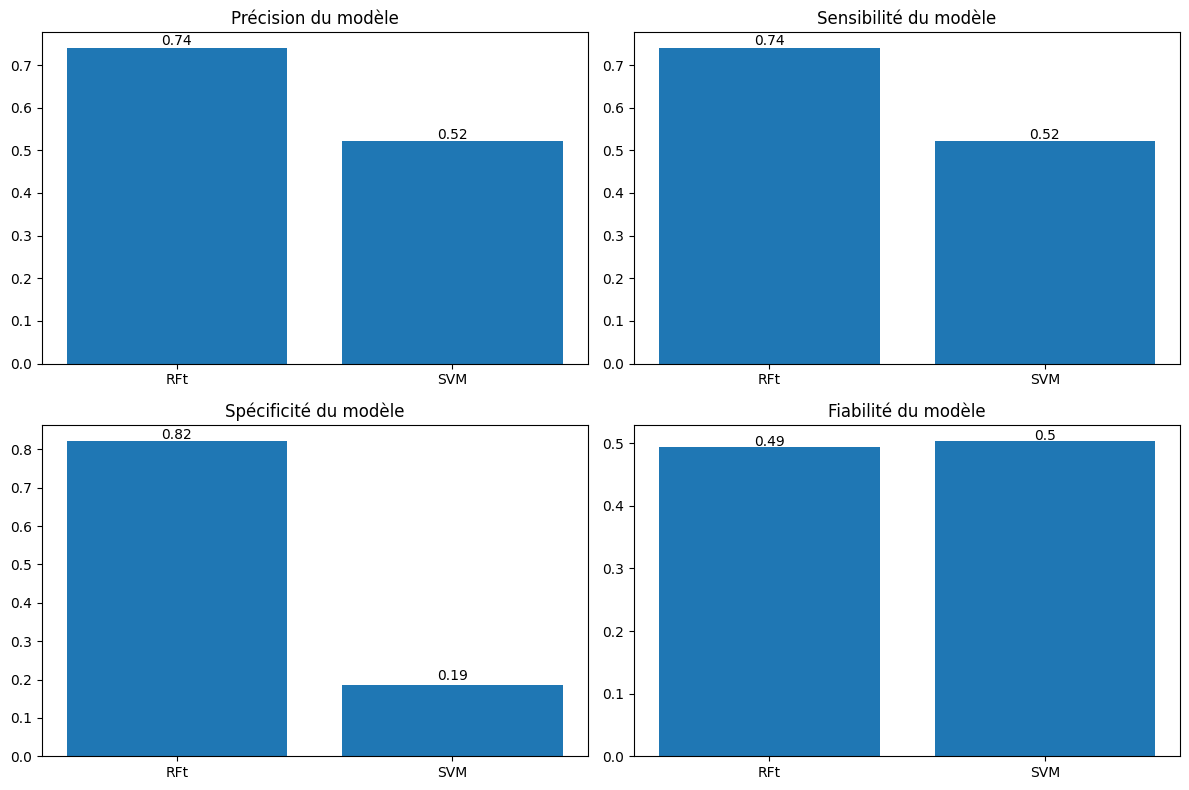

In [ ]:

#étape 2 ) à modifier
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



# Charger le DataFrame à partir du fichier CSV
chemin_csv_resultat_final = '/content/drive/MyDrive/Capgemini/dataframe/final.csv'
data = pd.read_csv(chemin_csv_resultat_final)

# Remplacer les NaN par 0
data = data.fillna(0)

# Ajouter la colonne 'niveau_somnolence'
data['KSS'] = data['video_name'].str.extract('kss#\d+-(\d+)').astype(float).fillna(0).astype(int)

# Définir les bins pour la classification
bins = [0, 3, 9]  # Regrouper les niveaux de KSS de 0 à 3 comme "alerte" et de 4 à 9 comme "somnolent"
labels = ['alerte', 'somnolent']
data['niveau_somnolence'] = pd.cut(data['KSS'], bins=bins, labels=labels)

# Compter le nombre de vidéos pour chaque niveau de somnolence
nombre_videos_par_niveau = data['niveau_somnolence'].value_counts()

# Afficher le résultat
print(nombre_videos_par_niveau)
# Afficher la taille du DataFrame
print("Taille du DataFrame :", data.shape)

# Remplacer les NaN par 0

# Extraction des colonnes appropriées pour X et y
X_columns = ['MAR_{}'.format(i) for i in range(875)] + \
            ['EAR_left_{}'.format(i) for i in range(875)] + \
            ['EAR_right_{}'.format(i) for i in range(875)] + \
            ['EAR_moyen_{}'.format(i) for i in range(875)] + \
            ['HOP_gd_{}'.format(i) for i in range(875)] + \
            ['HOP_hb_{}'.format(i) for i in range(875)] + \
            ['EBR_{}'.format(i) for i in range(875)] + \
            ['PERCLOS_{}'.format(i) for i in range(875)]

#kss 0(modèle binéire 0, 1 si elle commence à )

X = data[X_columns]
y = data['niveau_somnolence']

# Séparation des données en ensemble d'entraînement et ensemble de test,puis voir que ytrain
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.reset_index(drop=True,inplace=True)
print(X_train)
print(y)
print(y_test.value_counts())
print(y_train.value_counts())

# Liste des classifieurs à tester avec leurs acronymes respectifs
classifiers = {
    'RFt': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True)  # Activer la prédiction des probabilités
}

# Dictionnaires pour stocker les performances de chaque classifieur
accuracy_results = {}
sensibility_results = {}
specificity_results = {}
reliability_results = {}

# Entraînement, évaluation et collecte des performances pour chaque classifieur
for clf_name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Obtenir les probabilités pour la classe positive

    # Calcul des performances
    accuracy = accuracy_score(y_test, y_pred)
    sensibility = recall_score(y_test, y_pred, average='weighted')
    conf_matrix = confusion_matrix(y_test, y_pred)
    TN, FP, _, _ = conf_matrix.ravel()
    specificity = TN / (TN + FP)
    reliability = y_pred_proba.mean()

    # Stockage des performances
    accuracy_results[clf_name] = accuracy
    sensibility_results[clf_name] = sensibility
    specificity_results[clf_name] = specificity
    reliability_results[clf_name] = reliability

# Tracé des résultats pour chaque métrique
plt.figure(figsize=(12, 8))

print(conf_matrix)

# Précision
plt.subplot(2, 2, 1)
bars = plt.bar(accuracy_results.keys(), accuracy_results.values())
plt.title('Précision du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

# Sensibilité
plt.subplot(2, 2, 2)
bars = plt.bar(sensibility_results.keys(), sensibility_results.values())
plt.title('Sensibilité du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

# Spécificité
plt.subplot(2, 2, 3)
bars = plt.bar(specificity_results.keys(), specificity_results.values())
plt.title('Spécificité du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

# Fiabilité
plt.subplot(2, 2, 4)
bars = plt.bar(reliability_results.keys(), reliability_results.values())
plt.title('Fiabilité du modèle')
for bar in bars:
    yval = round(bar.get_height(), 2)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()


Modèle : RFt
Vrais Positifs (TP) : 82
Vrais Négatifs (TN) : 97
Faux Positifs (FP) : 21
Faux Négatifs (FN) : 42


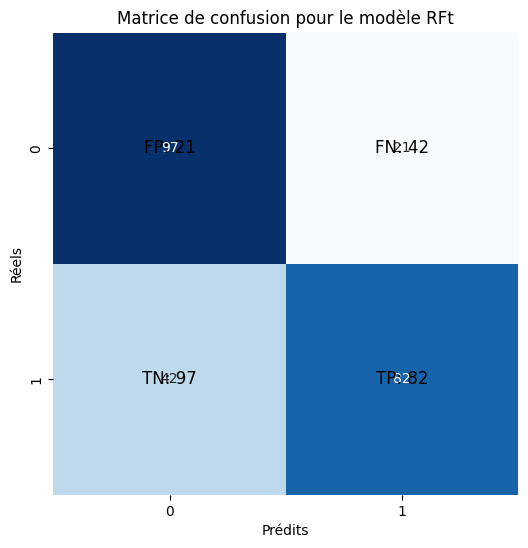

Modèle : SVM
Vrais Positifs (TP) : 104
Vrais Négatifs (TN) : 22
Faux Positifs (FP) : 96
Faux Négatifs (FN) : 20


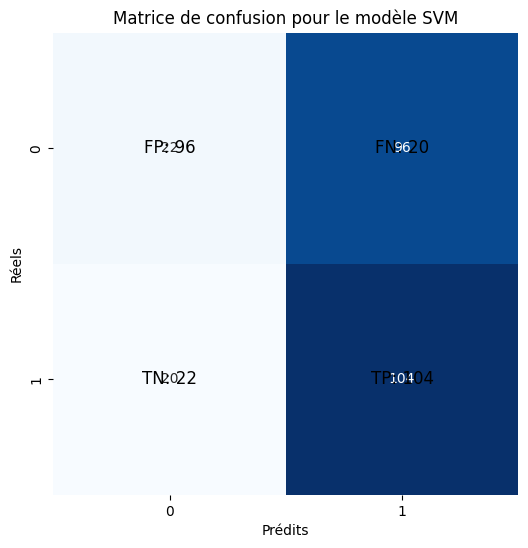

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

# Charger le DataFrame à partir du fichier CSV
chemin_csv_resultat_final = '/content/drive/MyDrive/Capgemini/dataframe/final.csv'
data = pd.read_csv(chemin_csv_resultat_final)

# Remplacer les NaN par 0
data = data.fillna(0)

# Ajouter la colonne 'niveau_somnolence'
data['KSS'] = data['video_name'].str.extract('kss#\d+-(\d+)').astype(float).fillna(0).astype(int)

# Définir les bins pour la classification
bins = [0, 3, 9]  # Regrouper les niveaux de KSS de 0 à 3 comme "alerte" et de 4 à 9 comme "somnolent"
labels = ['alerte', 'somnolent']
data['niveau_somnolence'] = pd.cut(data['KSS'], bins=bins, labels=labels)

# Extraction des colonnes appropriées pour X et y
X_columns = ['MAR_{}'.format(i) for i in range(875)] + \
            ['EAR_left_{}'.format(i) for i in range(875)] + \
            ['EAR_right_{}'.format(i) for i in range(875)] + \
            ['EAR_moyen_{}'.format(i) for i in range(875)] + \
            ['HOP_gd_{}'.format(i) for i in range(875)] + \
            ['HOP_hb_{}'.format(i) for i in range(875)] + \
            ['EBR_{}'.format(i) for i in range(875)] + \
            ['PERCLOS_{}'.format(i) for i in range(875)]

X = data[X_columns]
y = data['niveau_somnolence']

# Séparation des données en ensemble d'entraînement et ensemble de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.reset_index(drop=True, inplace=True)

# Liste des classifieurs à tester avec leurs acronymes respectifs
classifiers = {
    'RFt': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True)  # Activer la prédiction des probabilités
}

# Entraînement, évaluation et collecte des performances pour chaque classifieur
for clf_name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Calcul des TP, TN, FP, FN
    TP = conf_matrix[1, 1]  # Vrais Positifs : Les échantillons qui ont été correctement prédits comme appartenant à la classe positive
    TN = conf_matrix[0, 0]  # Vrais Négatifs : Les échantillons qui ont été correctement prédits comme n'appartenant pas à la classe positive
    FP = conf_matrix[0, 1]  # Faux Positifs : Les échantillons qui ont été incorrectement prédits comme appartenant à la classe positive (faux alarmes)
    FN = conf_matrix[1, 0]  # Faux Négatifs : Les échantillons qui ont été incorrectement prédits comme n'appartenant pas à la classe positive (omissions)

    print(f"Modèle : {clf_name}")
    print(f"Vrais Positifs (TP) : {TP}")
    print(f"Vrais Négatifs (TN) : {TN}")
    print(f"Faux Positifs (FP) : {FP}")
    print(f"Faux Négatifs (FN) : {FN}")

    # Affichage de la matrice de confusion avec annotations
    plt.figure(figsize=(6, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

    # Ajout des annotations pour chaque bloc de la matrice de confusion
    plt.text(0.5, 0.5, f'FP: {FP}', horizontalalignment='center', verticalalignment='center', fontsize=12, color='black')
    plt.text(1.5, 0.5, f'FN: {FN}', horizontalalignment='center', verticalalignment='center', fontsize=12, color='black')
    plt.text(0.5, 1.5, f'TN: {TN}', horizontalalignment='center', verticalalignment='center', fontsize=12, color='black')
    plt.text(1.5, 1.5, f'TP: {TP}', horizontalalignment='center', verticalalignment='center', fontsize=12, color='black')

    plt.xlabel('Prédits')
    plt.ylabel('Réels')
    plt.title(f'Matrice de confusion pour le modèle {clf_name}')
    plt.show()


In [ ]:
import pandas as pd

# Charger le DataFrame à partir du fichier CSV
chemin_csv_resultat_final = '/content/drive/MyDrive/Capgemini/dataframe/dataframe_final.csv'
data = pd.read_csv(chemin_csv_resultat_final)

# Extrayez le KSS à partir du nom de la vidéo
data['KSS'] = data['video_name'].str.extract('kss#\d+-(\d+)').astype(int)

# Définir les bins pour la classification
bins = [0, 3, 9]
labels = ['alerte', 'somnolent']
data['niveau_somnolence'] = pd.cut(data['KSS'], bins=bins, labels=labels)

# Compter le nombre de vidéos pour chaque niveau de somnolence
nombre_videos_par_niveau = data['niveau_somnolence'].value_counts()

# Afficher le résultat
print("Nombre de vidéos pour chaque niveau de somnolence :\n", nombre_videos_par_niveau)


Nombre de vidéos pour chaque niveau de somnolence :
 somnolent    506
alerte        13
Name: niveau_somnolence, dtype: int64


In [ ]:
import pandas as pd

# Charger le DataFrame à partir du fichier CSV
chemin_csv_resultat_final = '/content/drive/MyDrive/Capgemini/dataframe/dataframe_final.csv'
data = pd.read_csv(chemin_csv_resultat_final)

# Extrayez le KSS à partir du nom de la vidéo
data['KSS'] = data['video_name'].str.extract('kss#\d+-(\d+)').astype(int)

# Définir les bins pour la classification
bins = [0, 3, 9]
labels = ['alerte', 'somnolent']
data['niveau_somnolence'] = pd.cut(data['KSS'], bins=bins, labels=labels)

# Filtrer les vidéos avec KSS somnolent
videos_somnolentes = data[data['niveau_somnolence'] == 'somnolent']['video_name']

# Filtrer les vidéos avec KSS alerte
videos_alertes = data[data['niveau_somnolence'] == 'alerte']['video_name']

# Afficher la liste des noms de vidéos avec KSS somnolent
print("Vidéos avec KSS somnolent :\n", videos_somnolentes)

# Afficher la liste des noms de vidéos avec KSS alerte
print("\nVidéos avec KSS alerte :\n", videos_alertes)


Vidéos avec KSS somnolent :
 0      /content/drive/MyDrive/Capgemini/videos/kss#8-...
1      /content/drive/MyDrive/Capgemini/videos/kss#8-...
2      /content/drive/MyDrive/Capgemini/videos/kss#8-...
3      /content/drive/MyDrive/Capgemini/videos/kss#8-...
4      /content/drive/MyDrive/Capgemini/videos/kss#6-...
                             ...                        
514    /content/drive/MyDrive/Capgemini/videos/kss#8-...
515    /content/drive/MyDrive/Capgemini/videos/kss#6-...
516    /content/drive/MyDrive/Capgemini/videos/kss#8-...
517    /content/drive/MyDrive/Capgemini/videos/kss#8-...
518    /content/drive/MyDrive/Capgemini/videos/kss#8-...
Name: video_name, Length: 506, dtype: object

Vidéos avec KSS alerte :
 501    /content/drive/MyDrive/Capgemini/videos/kss#1-...
502    /content/drive/MyDrive/Capgemini/videos/kss#1-...
503    /content/drive/MyDrive/Capgemini/videos/kss#1-...
504    /content/drive/MyDrive/Capgemini/videos/kss#1-...
505    /content/drive/MyDrive/Capgemini/vide

In [ ]:
import pandas as pd

# Charger le DataFrame à partir du fichier CSV
chemin_csv_resultat_final = '/content/drive/MyDrive/Capgemini/dataframe/dataframe_final.csv'
data = pd.read_csv(chemin_csv_resultat_final)

# Extrayez le KSS à partir du nom de la vidéo
data['KSS'] = data['video_name'].str.extract('kss#\d+-(\d+)').astype(int)

# Définir les bins pour la classification
bins = [0, 3, 9]
labels = ['alerte', 'somnolent']
data['niveau_somnolence'] = pd.cut(data['KSS'], bins=bins, labels=labels)

# Filtrer les vidéos avec KSS somnolent
videos_somnolentes = data[data['niveau_somnolence'] == 'somnolent']['video_name']

# Filtrer les vidéos avec KSS alerte
videos_alertes = data[data['niveau_somnolence'] == 'alerte']['video_name']

# Enregistrer les noms des vidéos dans des fichiers texte
with open('/content/drive/MyDrive/Capgemini/dataframe/videos_somnolentes.txt', 'w') as f:
    f.write('\n'.join(videos_somnolentes))

with open('/content/drive/MyDrive/Capgemini/dataframe/videos_alertes.txt', 'w') as f:
    f.write('\n'.join(videos_alertes))


In [ ]:
# Chemin du fichier contenant les noms de vidéos alertes
fichier_alertes = '/content/drive/MyDrive/Capgemini/dataframe/videos_alertes.txt'

# Chemin du dossier contenant les vidéos 1.3alerte
dossier_videos = '/content/drive/MyDrive/Capgemini/1.3alerte/'

# Lire les noms de vidéos alertes depuis le fichier texte
with open(fichier_alertes, 'r') as f:
    noms_videos_alertes = f.read().splitlines()

# Initialiser le compteur de vidéos alertes dans le dossier 1.3alerte
nombre_videos_alertes_dossier = 0

# Parcourir les fichiers dans le dossier 1.3alerte
for nom_video in os.listdir(dossier_videos):
    # Construire le chemin complet du fichier vidéo
    chemin_video = os.path.join('/content/drive/MyDrive/Capgemini/videos/', nom_video)
    # Vérifier si le nom de la vidéo est dans la liste des vidéos alertes
    if chemin_video in noms_videos_alertes:
        nombre_videos_alertes_dossier += 1

# Compter le nombre total de vidéos dans le dossier 1.3alerte
nombre_total_videos_dossier = len(os.listdir(dossier_videos))

# Afficher le résultat
print("{0} alertes sur {1} vidéos sont dans les {2} vidéos du dossier 1.3alerte".format(
    nombre_videos_alertes_dossier, len(noms_videos_alertes), nombre_total_videos_dossier))


13 alertes sur 13 vidéos sont dans les 603 vidéos du dossier 1.3alerte


In [ ]:
# Chemin du fichier contenant les noms de vidéos alertes
fichier_alertes = '/content/drive/MyDrive/Capgemini/dataframe/videos_somnolentes.txt'

# Chemin du dossier contenant les vidéos 1.3alerte
dossier_videos = '/content/drive/MyDrive/Capgemini/7.9somnolent/'

# Lire les noms de vidéos alertes depuis le fichier texte
with open(fichier_alertes, 'r') as f:
    noms_videos_alertes = f.read().splitlines()

# Initialiser le compteur de vidéos alertes dans le dossier 1.3alerte
nombre_videos_alertes_dossier = 0

# Parcourir les fichiers dans le dossier 1.3alerte
for nom_video in os.listdir(dossier_videos):
    # Construire le chemin complet du fichier vidéo
    chemin_video = os.path.join('/content/drive/MyDrive/Capgemini/videos/', nom_video)
    # Vérifier si le nom de la vidéo est dans la liste des vidéos alertes
    if chemin_video in noms_videos_alertes:
        nombre_videos_alertes_dossier += 1

# Compter le nombre total de vidéos dans le dossier 1.3alerte
nombre_total_videos_dossier = len(os.listdir(dossier_videos))

# Afficher le résultat
print("{0} alertes sur {1} vidéos sont dans les {2} vidéos du dossier 1.3alerte".format(
    nombre_videos_alertes_dossier, len(noms_videos_alertes), nombre_total_videos_dossier))


506 alertes sur 506 vidéos sont dans les 603 vidéos du dossier 1.3alerte


In [ ]:
import os

# Chemin du fichier contenant les noms de vidéos alertes
fichier_alertes = '/content/drive/MyDrive/Capgemini/dataframe/videos_alertes.txt'

# Chemin du dossier contenant les vidéos 1.3alerte
dossier_videos = '/content/drive/MyDrive/Capgemini/1.3alerte/'

# Chemin du fichier pour enregistrer les noms de vidéos manquantes
fichier_videos_manquantes = '/content/drive/MyDrive/Capgemini/dataframe/videoalertemanquante.txt'

# Lire les noms de vidéos alertes depuis le fichier texte
with open(fichier_alertes, 'r') as f:
    noms_videos_alertes = f.read().splitlines()

# Initialiser une liste pour stocker les noms de vidéos manquantes
videos_manquantes = []

# Parcourir les fichiers dans le dossier 1.3alerte
for nom_video in os.listdir(dossier_videos):
    # Construire le chemin complet du fichier vidéo
    chemin_video = os.path.join('/content/drive/MyDrive/Capgemini/videos/', nom_video)
    # Vérifier si le nom de la vidéo est dans la liste des vidéos alertes
    if chemin_video not in noms_videos_alertes:
        videos_manquantes.append(nom_video)

# Compter le nombre de vidéos manquantes
nombre_videos_manquantes = len(videos_manquantes)

# Enregistrer les noms de vidéos manquantes dans un fichier texte
with open(fichier_videos_manquantes, 'w') as f:
    f.write('\n'.join(videos_manquantes))

# Afficher le résultat
print("Nombre de vidéos manquantes dans le dossier 1.3alerte :", nombre_videos_manquantes)


Nombre de vidéos manquantes dans le dossier 1.3alerte : 590


In [ ]:
import os

# Chemin du fichier contenant les noms de vidéos somnolentes
fichier_somnolentes = '/content/drive/MyDrive/Capgemini/dataframe/videos_somnolentes.txt'

# Chemin du dossier contenant les vidéos 7.9somnolent
dossier_videos_somnolentes = '/content/drive/MyDrive/Capgemini/7.9somnolent/'

# Chemin du fichier pour enregistrer les noms de vidéos somnolentes manquantes
fichier_videos_somnolentes_manquantes = '/content/drive/MyDrive/Capgemini/dataframe/videosomnolentmanquante.txt'

# Lire les noms de vidéos somnolentes depuis le fichier texte
with open(fichier_somnolentes, 'r') as f:
    noms_videos_somnolentes = f.read().splitlines()

# Initialiser une liste pour stocker les noms de vidéos somnolentes manquantes
videos_somnolentes_manquantes = []

# Parcourir les fichiers dans le dossier 7.9somnolent
for nom_video in os.listdir(dossier_videos_somnolentes):
    # Construire le chemin complet du fichier vidéo
    chemin_video = os.path.join('/content/drive/MyDrive/Capgemini/videos/', nom_video)
    # Vérifier si le nom de la vidéo est dans la liste des vidéos somnolentes
    if chemin_video not in noms_videos_somnolentes:
        videos_somnolentes_manquantes.append(nom_video)

# Compter le nombre de vidéos somnolentes manquantes
nombre_videos_somnolentes_manquantes = len(videos_somnolentes_manquantes)

# Enregistrer les noms de vidéos somnolentes manquantes dans un fichier texte
with open(fichier_videos_somnolentes_manquantes, 'w') as f:
    f.write('\n'.join(videos_somnolentes_manquantes))

# Afficher le résultat
print("Nombre de vidéos somnolentes manquantes dans le dossier 7.9somnolent :", nombre_videos_somnolentes_manquantes)


Nombre de vidéos somnolentes manquantes dans le dossier 7.9somnolent : 97


In [ ]:
import os
import shutil

# Chemin du fichier contenant les noms de vidéos manquantes
fichier_videos_manquantes = '/content/drive/MyDrive/Capgemini/dataframe/videoalertemanquante.txt'

# Chemin du dossier contenant les vidéos 1.3alerte
dossier_videos_alerte = '/content/drive/MyDrive/Capgemini/1.3alerte/'

# Chemin du dossier pour les vidéos manquantes
dossier_videos_manquantes = '/content/drive/MyDrive/Capgemini/videosalertemanquant/'

# Compter le nombre initial de vidéos dans le dossier des vidéos manquantes
nombre_initial_videos_manquantes = len(os.listdir(dossier_videos_manquantes))

# Lire les noms de vidéos manquantes depuis le fichier texte
with open(fichier_videos_manquantes, 'r') as f:
    noms_videos_manquantes = f.read().splitlines()

# Initialiser le compteur de vidéos déplacées
videos_deplacees = 0

# Parcourir les fichiers dans le dossier 1.3alerte
for nom_video in os.listdir(dossier_videos_alerte):
    # Vérifier si le nom de la vidéo est dans la liste des vidéos manquantes
    if nom_video in noms_videos_manquantes:
        # Construire le chemin complet du fichier vidéo
        chemin_video = os.path.join(dossier_videos_alerte, nom_video)
        # Déplacer la vidéo vers le dossier des vidéos manquantes
        shutil.move(chemin_video, dossier_videos_manquantes)
        videos_deplacees += 1

# Afficher le nombre de vidéos déplacées dans le dossier des vidéos manquantes
print("Nombre de vidéos déplacées dans le dossier des vidéos manquantes :", videos_deplacees)

# Compter le nombre final de vidéos dans le dossier des vidéos manquantes
nombre_final_videos_manquantes = len(os.listdir(dossier_videos_manquantes))

# Afficher le nombre total de vidéos dans le dossier des vidéos manquantes
print("Nombre total de vidéos dans le dossier des vidéos manquantes :", nombre_final_videos_manquantes)


Nombre de vidéos déplacées dans le dossier des vidéos manquantes : 590
Nombre total de vidéos dans le dossier des vidéos manquantes : 590


In [ ]:
import os
import shutil

# Chemin du fichier contenant les noms de vidéos manquantes
fichier_videos_manquantes = '/content/drive/MyDrive/Capgemini/dataframe/videosomnolentmanquante.txt'

# Chemin du dossier contenant les vidéos 7.9somnolent
dossier_videos_somnolentes = '/content/drive/MyDrive/Capgemini/7.9somnolent/'

# Chemin du dossier pour les vidéos manquantes
dossier_videos_manquantes = '/content/drive/MyDrive/Capgemini/videosomnolentmanquant/'

# Compter le nombre initial de vidéos dans le dossier des vidéos manquantes
nombre_initial_videos_manquantes = len(os.listdir(dossier_videos_manquantes))

# Lire les noms de vidéos manquantes depuis le fichier texte
with open(fichier_videos_manquantes, 'r') as f:
    noms_videos_manquantes = f.read().splitlines()

# Initialiser le compteur de vidéos déplacées
videos_deplacees = 0

# Parcourir les fichiers dans le dossier 7.9somnolent
for nom_video in os.listdir(dossier_videos_somnolentes):
    # Vérifier si le nom de la vidéo est dans la liste des vidéos manquantes
    if nom_video in noms_videos_manquantes:
        # Construire le chemin complet du fichier vidéo
        chemin_video = os.path.join(dossier_videos_somnolentes, nom_video)
        # Déplacer la vidéo vers le dossier des vidéos manquantes
        shutil.move(chemin_video, dossier_videos_manquantes)
        videos_deplacees += 1

# Afficher le nombre de vidéos déplacées dans le dossier des vidéos manquantes
print("Nombre de vidéos déplacées dans le dossier des vidéos manquantes :", videos_deplacees)

# Compter le nombre final de vidéos dans le dossier des vidéos manquantes
nombre_final_videos_manquantes = len(os.listdir(dossier_videos_manquantes))

# Afficher le nombre total de vidéos dans le dossier des vidéos manquantes
print("Nombre total de vidéos dans le dossier des vidéos manquantes :", nombre_final_videos_manquantes)


Nombre de vidéos déplacées dans le dossier des vidéos manquantes : 97
Nombre total de vidéos dans le dossier des vidéos manquantes : 97


In [ ]:
import os
import shutil

# Chemin du dossier source
source_folder = '/content/drive/MyDrive/Capgemini/videosomnolentmanquant/'

# Chemin du dossier de destination
destination_folder = '/content/drive/MyDrive/Capgemini/videosomnolentmanquant/videolocal/'

# Liste des vidéos à déplacer
videos_to_move = os.listdir(source_folder)[:95]

# Créer le dossier de destination s'il n'existe pas
os.makedirs(destination_folder, exist_ok=True)

# Boucle pour déplacer chaque vidéo
for video_name in videos_to_move:
    source_path = os.path.join(source_folder, video_name)
    destination_path = os.path.join(destination_folder, video_name)
    shutil.move(source_path, destination_path)

# Afficher un message de confirmation
print("Les vidéos ont été déplacées avec succès vers le dossier de destination.")


Les vidéos ont été déplacées avec succès vers le dossier de destination.
